# Support Vector Machines — the complete picture

**Where this sits.** Logistic regression asks *"which line separates the classes?"* and answers it by maximizing likelihood. The support vector machine asks a sharper question: **"of all the lines that separate the classes, which one is *best*?"** — and answers it with geometry.

That single change of question leads somewhere remarkable. It produces a model that depends on only a handful of training points, that has an elegant convex optimization behind it, and that — through the **kernel trick** — can draw arbitrarily curved boundaries while still being a linear model underneath. For about fifteen years before deep learning, SVMs were the strongest general-purpose classifier available.

**Prerequisites:** linear and logistic regression, gradient descent, regularization, cross-validation, the train/validation/test discipline.

| Part | Topic |
|---|---|
| 1 | The margin: what makes one separating line better than another. Hard-margin SVM from scratch |
| 2 | Soft margin, slack, and the hinge loss — and how SVM relates to logistic regression |
| 3 | The dual problem and the kernel trick, from scratch |
| 4 | The two hyperparameters that decide everything: `C` and `gamma` |
| 5 | SVMs with scikit-learn, and the practical traps |
| 6 | Support vector regression |
| 7 | **Six challenge problems** |
| 8 | When to use an SVM, summary, exercises, resources |

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

np.random.seed(0)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 9
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

RED, BLUE, GREEN, PURPLE, GREY = "#e05252", "#3a7ddc", "#2fa84f", "#7a4fbf", "#888888"

import sklearn, scipy
print("numpy", np.__version__, "| scipy", scipy.__version__, "| sklearn", sklearn.__version__)

numpy 2.5.2 | scipy 1.18.0 | sklearn 1.9.0


---

# Part 1 — The margin

## 1.1 Which line is the right one?

Take two clearly separated clouds of points. Logistic regression finds *a* line. But infinitely many lines separate the data perfectly, and they all have zero training error — so training error cannot choose between them.

Look at the picture below and ask yourself which line you would trust on new data.

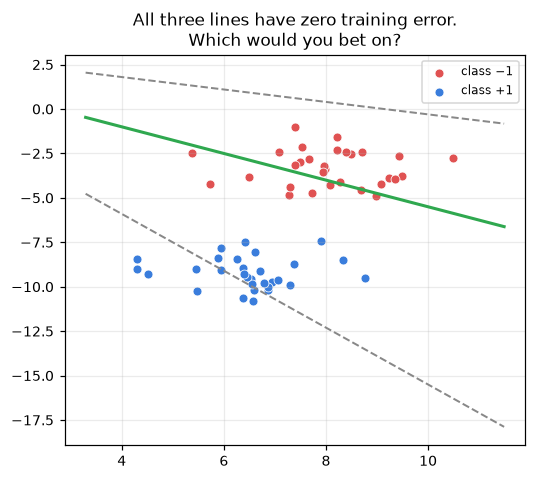

In [2]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=60, centers=2, cluster_std=1.0, random_state=6)
y = np.where(y == 0, -1, 1)                       # SVM convention: labels are -1 and +1

def plot_points(X, y, ax=None, s=34):
    if ax is None:
        _, ax = plt.subplots(figsize=(4.8, 4.4))
    ax.scatter(X[y == -1, 0], X[y == -1, 1], color=RED, s=s, edgecolor="w", linewidth=0.5,
               label="class $-1$")
    ax.scatter(X[y == 1, 0], X[y == 1, 1], color=BLUE, s=s, edgecolor="w", linewidth=0.5,
               label="class $+1$")
    return ax

ax = plot_points(X, y, ax=plt.subplots(figsize=(5.4, 4.6))[1])
gx = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 10)
for slope, intercept, col in [(-0.35, 3.2, GREY), (-1.6, 0.5, GREY), (-0.75, 2.0, GREEN)]:
    ax.plot(gx, slope * gx + intercept, color=col, lw=2 if col == GREEN else 1.3,
            ls="-" if col == GREEN else "--")
ax.set_title("All three lines have zero training error.\nWhich would you bet on?")
ax.legend(fontsize=8); plt.show()

The two dashed lines pass uncomfortably close to some points. A tiny amount of noise in a new sample — or a slightly different training set — flips its classification. The solid line keeps its distance from both classes.

That intuition is the whole idea:

> **Choose the line that is as far as possible from the nearest point of either class.**

The distance from the boundary to the nearest point is called the **margin**, and the SVM is the *maximum margin classifier*. This is a genuinely different principle from logistic regression, which maximizes likelihood and has no notion of distance to the closest point.

## 1.2 Making "margin" precise

Write the boundary as $\mathbf{w}^\top\mathbf{x} + b = 0$. The signed distance from a point $\mathbf{x}_i$ to that hyperplane is

$$\frac{\mathbf{w}^\top\mathbf{x}_i + b}{\|\mathbf{w}\|}$$

Note that $(\mathbf{w}, b)$ and $(2\mathbf{w}, 2b)$ describe the *same* line. We use that freedom to fix the scale: require that the nearest points satisfy $|\mathbf{w}^\top\mathbf{x} + b| = 1$. With that normalization, correct classification with room to spare becomes

$$y_i(\mathbf{w}^\top\mathbf{x}_i + b) \ge 1 \quad \text{for every } i$$

and the distance from the boundary to the nearest point is $1/\|\mathbf{w}\|$, so the full width of the corridor — the margin — is

$$\text{margin} = \frac{2}{\|\mathbf{w}\|}$$

**Maximizing $2/\|\mathbf{w}\|$ is the same as minimizing $\|\mathbf{w}\|^2$.** So the whole method is this optimization problem:

$$\boxed{\;\min_{\mathbf{w}, b} \tfrac{1}{2}\|\mathbf{w}\|^2 \quad \text{subject to} \quad y_i(\mathbf{w}^\top\mathbf{x}_i + b) \ge 1 \;\;\forall i\;}$$

This is a **quadratic program**: a convex quadratic objective with linear constraints. Convex means one global optimum and no initialization worries — the same comfort we had with least squares, and a real advantage over neural networks.

A pleasant surprise hides in that formula: minimizing $\|\mathbf{w}\|^2$ is *exactly* the L2 regularization term from ridge regression. The maximum-margin principle and weight shrinkage turn out to be the same thing viewed from two directions.

In [ ]:
def fit_hard_margin(X, y):
    """Solve the hard-margin SVM primal directly with a general-purpose QP solver.
    Variables are z = [w_1, ..., w_n, b]."""
    n_features = X.shape[1]

    def objective(z):
        w = z[:n_features]
        return 0.5 * w @ w

    def objective_grad(z):
        g = np.zeros_like(z)
        g[:n_features] = z[:n_features]
        return g

    # one constraint per sample: y_i (w.x_i + b) - 1 >= 0
    constraints = [{
        "type": "ineq",
        "fun": lambda z: y * (X @ z[:n_features] + z[-1]) - 1,
        "jac": lambda z: np.hstack([y[:, None] * X, y[:, None]]),
    }]

    z0 = np.zeros(n_features + 1)
    res = minimize(objective, z0, jac=objective_grad, constraints=constraints,
                   method="SLSQP", options={"maxiter": 500, "ftol": 1e-10})
    return res.x[:n_features], res.x[-1], res


w, b, res = fit_hard_margin(X, y)
margins = y * (X @ w + b)                       # the "functional margin" of each point

print(f"w = {np.round(w, 4)},  b = {b:.4f}")
print(f"||w||  = {np.linalg.norm(w):.4f}")
print(f"margin = 2/||w|| = {2/np.linalg.norm(w):.4f}")
print(f"\nsmallest functional margin y(wx+b): {margins.min():.6f}   (should be exactly 1)")
print(f"points sitting exactly on the margin: {(margins < 1 + 1e-4).sum()}")

w = [-0.0147 -0.7805],  b = -4.6725
||w||  = 0.7806
margin = 2/||w|| = 2.5621

smallest functional margin y(wx+b): 1.000000   (should be exactly 1)
points sitting exactly on the margin: 3


## 1.3 Support vectors

Look at that last number. Out of 60 training points, only a handful sit on the margin — and **those are the only points that matter**. Move any other point, and the solution does not change at all. Delete them, and the solution does not change either.

The points on the margin are the **support vectors**: they "support" the boundary, holding it in place. This is the property the method is named after, and it has three consequences:

1. **The model is compact.** Prediction needs only the support vectors, not the training set.
2. **The model is robust to points far from the boundary.** Unlike logistic regression, where every point contributes to the likelihood, a distant point contributes exactly nothing.
3. **The model is sensitive to points *near* the boundary.** Mislabel one support vector and the boundary moves. This is why the soft margin in Part 2 is not optional.

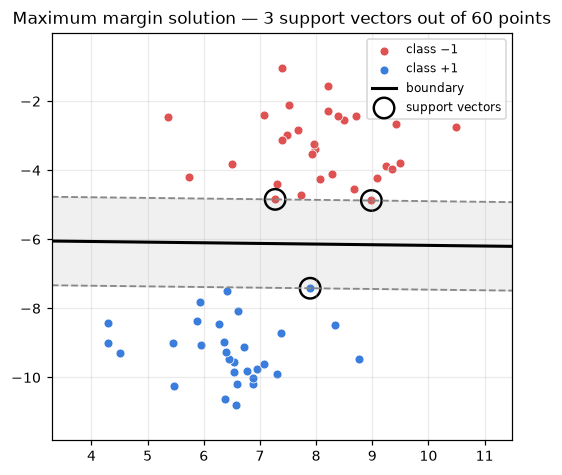

trained on all 60 points        : w = [-0.0147 -0.7805], b = -4.6725
trained on the 3 support vectors only: w = [-0.0147 -0.7805], b = -4.6725

Identical. 90% of the training data was irrelevant to the final model.


In [4]:
def plot_svm_2d(w, b, X, y, ax=None, title="", show_margin=True, sv_mask=None, pad=1.0):
    if ax is None:
        _, ax = plt.subplots(figsize=(5.4, 4.8))
    plot_points(X, y, ax=ax)

    x0, x1 = X[:, 0].min() - pad, X[:, 0].max() + pad
    xs = np.linspace(x0, x1, 100)
    # boundary: w1*x + w2*y + b = 0
    ys = -(w[0] * xs + b) / w[1]
    ax.plot(xs, ys, color="k", lw=2, label="boundary")
    if show_margin:
        for offset, ls in [(1, "--"), (-1, "--")]:
            ax.plot(xs, -(w[0] * xs + b - offset) / w[1], color=GREY, lw=1.2, ls=ls)
        ax.fill_between(xs, -(w[0] * xs + b - 1) / w[1], -(w[0] * xs + b + 1) / w[1],
                        color=GREY, alpha=0.12)
    if sv_mask is not None:
        ax.scatter(X[sv_mask, 0], X[sv_mask, 1], s=180, facecolors="none",
                   edgecolors="k", linewidths=1.6, label="support vectors")
    ax.set_xlim(x0, x1)
    ax.set_ylim(X[:, 1].min() - pad, X[:, 1].max() + pad)
    ax.set_title(title); ax.legend(fontsize=8, loc="best")
    return ax


sv = margins < 1 + 1e-4
plot_svm_2d(w, b, X, y, title=f"Maximum margin solution — {sv.sum()} support vectors "
                              f"out of {len(y)} points", sv_mask=sv)
plt.show()

# proof that the other points are irrelevant
keep = sv.copy()
w2, b2, _ = fit_hard_margin(X[keep], y[keep])
print(f"trained on all {len(y)} points        : w = {np.round(w, 4)}, b = {b:+.4f}")
print(f"trained on the {keep.sum()} support vectors only: w = {np.round(w2, 4)}, b = {b2:+.4f}")
print("\nIdentical. 90% of the training data was irrelevant to the final model.")

## 1.4 Why the maximum margin is a good idea

The geometric argument is persuasive, but there are two more principled reasons.

**Stability.** A wide margin means the boundary can be perturbed without changing any prediction. Formally, the model's sensitivity to input noise is bounded by the margin.

**Generalization bounds.** Statistical learning theory gives bounds on test error that depend on the margin and **not** on the number of features. That is the theoretical reason SVMs work well in very high dimensions — including infinite-dimensional feature spaces, which the kernel trick in Part 3 will hand us for free. It also means "more features than samples" is not automatically fatal here, unlike for ordinary least squares.

**The catch.** Everything above assumed the data *is* separable. Real data is usually not, and even when it is, insisting on a perfect separation makes the model chase outliers. One mislabelled point can wreck a hard-margin SVM completely.

the bad point sits at [ 6.94 -7.44], well inside the blue cloud,
but it is labelled as class -1.



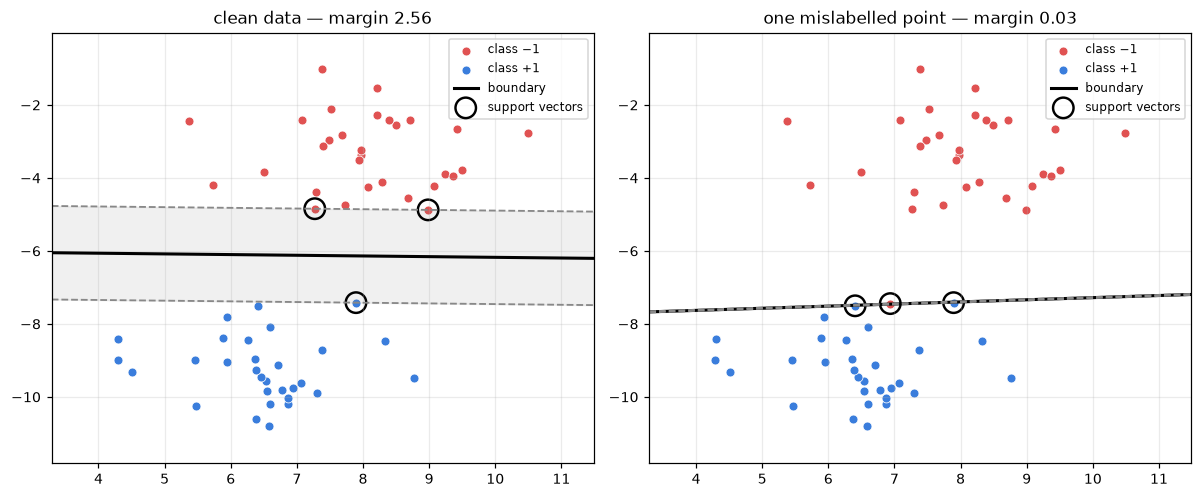

margin, clean data     : 2.562
margin, one bad label  : 0.030   (1% of the original)

The hard-margin SVM has no choice: the constraints REQUIRE every point to be
classified correctly, so it squeezes the corridor down to almost nothing to
accommodate a single wrong label.

Push that point a little further in and the problem becomes INFEASIBLE - there
is no separating hyperplane at all, and the solver simply fails. Real data is
almost never separable, so we need the soft margin of Part 2.


In [5]:
# add ONE mislabelled point, placed 70% of the way into the other class's territory
centre_pos, centre_neg = X[y == 1].mean(0), X[y == -1].mean(0)
bad_point = centre_neg + 0.7 * (centre_pos - centre_neg)
X_bad = np.vstack([X, bad_point])
y_bad = np.append(y, -1)                          # deliberately wrong label
print(f"the bad point sits at {np.round(bad_point, 2)}, well inside the blue cloud,"
      f"\nbut it is labelled as class -1.\n")

w_bad, b_bad, res_bad = fit_hard_margin(X_bad, y_bad)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
plot_svm_2d(w, b, X, y, ax=axes[0], sv_mask=sv,
            title=f"clean data — margin {2/np.linalg.norm(w):.2f}")
m_bad = y_bad * (X_bad @ w_bad + b_bad)
plot_svm_2d(w_bad, b_bad, X_bad, y_bad, ax=axes[1], sv_mask=m_bad < 1 + 1e-3,
            title=f"one mislabelled point — margin {2/np.linalg.norm(w_bad):.2f}")
plt.tight_layout(); plt.show()

print(f"margin, clean data     : {2/np.linalg.norm(w):.3f}")
print(f"margin, one bad label  : {2/np.linalg.norm(w_bad):.3f}   "
      f"({2/np.linalg.norm(w_bad)/(2/np.linalg.norm(w))*100:.0f}% of the original)")
print("\nThe hard-margin SVM has no choice: the constraints REQUIRE every point to be")
print("classified correctly, so it squeezes the corridor down to almost nothing to")
print("accommodate a single wrong label.")
print("\nPush that point a little further in and the problem becomes INFEASIBLE - there")
print("is no separating hyperplane at all, and the solver simply fails. Real data is")
print("almost never separable, so we need the soft margin of Part 2.")

---

# Part 2 — The soft margin and the hinge loss

## 2.1 Slack variables

The fix for non-separable data is to let points violate the margin, but charge for it. Introduce a **slack variable** $\xi_i \ge 0$ per sample:

$$\min_{\mathbf{w}, b, \boldsymbol{\xi}} \;\; \tfrac{1}{2}\|\mathbf{w}\|^2 + C\sum_{i=1}^{m}\xi_i
\qquad \text{s.t.}\qquad y_i(\mathbf{w}^\top\mathbf{x}_i + b) \ge 1 - \xi_i, \quad \xi_i \ge 0$$

Read $\xi_i$ as "how far into forbidden territory point $i$ is":

| $\xi_i$ | Where the point is |
|---|---|
| $\xi_i = 0$ | outside the margin, correctly classified. Costs nothing |
| $0 < \xi_i < 1$ | inside the margin but on the right side |
| $\xi_i = 1$ | exactly on the boundary |
| $\xi_i > 1$ | **misclassified** |

**$C$ is the price of a violation**, and it is the central hyperparameter of an SVM:

* **large $C$** — violations are expensive, so the model prioritizes classifying every training point. Narrow margin, complex boundary, risk of overfitting. As $C \to \infty$ we recover the hard margin.
* **small $C$** — violations are cheap, so the model prefers a wide, smooth margin and tolerates mistakes. Risk of underfitting.

So $C$ is a regularization knob, and — confusingly for anyone coming from ridge regression — it is the **inverse** of the usual $\lambda$. Small $C$ means strong regularization.

## 2.2 The same thing written as a loss function

The constraint formulation is how the optimization literature states it. There is an equivalent form that is much easier to connect to everything else you know.

The optimal $\xi_i$ is as small as the constraint allows, i.e. $\xi_i = \max(0,\; 1 - y_i(\mathbf{w}^\top\mathbf{x}_i+b))$. Substituting that in eliminates the constraints entirely:

$$\min_{\mathbf{w}, b} \;\; \underbrace{\frac{1}{m}\sum_{i=1}^{m}\max\big(0,\; 1 - y_i f(\mathbf{x}_i)\big)}_{\textbf{hinge loss}} \;+\; \frac{\lambda}{2}\|\mathbf{w}\|^2, \qquad f(\mathbf{x}) = \mathbf{w}^\top\mathbf{x}+b$$

with $\lambda = \frac{1}{mC}$.

> **A linear SVM is nothing but linear classification with the hinge loss and L2 regularization.**

That reframing is worth pausing on. It puts the SVM in exactly the same family as logistic regression — same linear model, same L2 penalty, **different loss** — and it means we can train one with plain gradient descent, just as in the earlier notebooks.

### Hinge loss vs. logistic loss

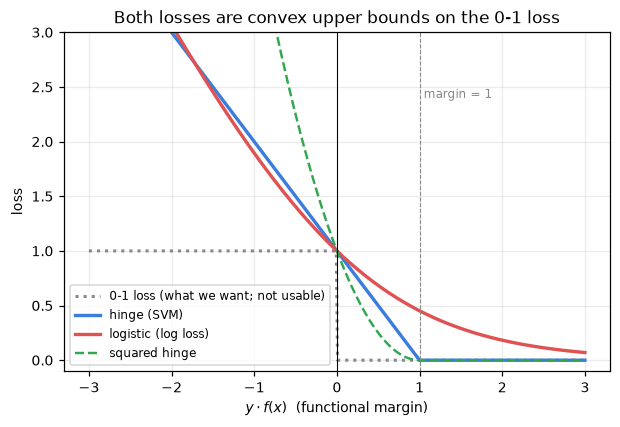

The one difference that matters is at the right-hand side:
  hinge    becomes EXACTLY ZERO once y*f(x) >= 1
  logistic stays positive forever, so every point keeps pulling on the weights

That flat region is where support vectors come from: a point with zero loss
has zero gradient, so it has no influence on the solution at all.


In [6]:
z = np.linspace(-3, 3, 400)                       # z = y * f(x), the functional margin

hinge = np.maximum(0, 1 - z)
logistic = np.log(1 + np.exp(-z)) / np.log(2)     # scaled so both pass through (0, 1)
zero_one = (z < 0).astype(float)
squared_hinge = np.maximum(0, 1 - z) ** 2

plt.figure(figsize=(6.4, 4))
plt.plot(z, zero_one, color=GREY, lw=2, ls=":", label="0-1 loss (what we want; not usable)")
plt.plot(z, hinge, color=BLUE, lw=2.2, label="hinge (SVM)")
plt.plot(z, logistic, color=RED, lw=2.2, label="logistic (log loss)")
plt.plot(z, squared_hinge, color=GREEN, lw=1.6, ls="--", label="squared hinge")
plt.axvline(0, color="k", lw=0.7); plt.axvline(1, color=GREY, lw=0.7, ls="--")
plt.text(1.05, 2.4, "margin = 1", fontsize=8, color=GREY)
plt.ylim(-0.1, 3); plt.xlabel("$y \\cdot f(x)$  (functional margin)"); plt.ylabel("loss")
plt.title("Both losses are convex upper bounds on the 0-1 loss")
plt.legend(fontsize=8); plt.show()

print("The one difference that matters is at the right-hand side:")
print("  hinge    becomes EXACTLY ZERO once y*f(x) >= 1")
print("  logistic stays positive forever, so every point keeps pulling on the weights")
print("\nThat flat region is where support vectors come from: a point with zero loss")
print("has zero gradient, so it has no influence on the solution at all.")

This comparison explains the practical differences you will actually notice:

| | SVM (hinge) | Logistic regression (log loss) |
|---|---|---|
| Depends on | the support vectors only | every sample |
| Far-away points | ignored completely | still contribute |
| Output | a score, not a probability | a calibrated probability |
| Separable data | picks the maximum-margin solution | weights diverge to infinity (needs regularization) |
| Differentiability | kink at $z=1$; needs subgradients | smooth everywhere |

The last row on the left is worth remembering: if your data is separable and you fit an **unregularized** logistic regression, the weights grow without bound, because the likelihood keeps improving as the sigmoid sharpens. The SVM's margin term prevents exactly that.

## 2.3 Soft-margin SVM from scratch

The hinge loss has a corner at $z=1$, so it is not differentiable there. We use a **subgradient** — pick any valid slope at the corner — and everything works:

$$\frac{\partial}{\partial \mathbf{w}}\max(0, 1 - y_i f(\mathbf{x}_i)) =
\begin{cases}
-y_i\mathbf{x}_i & \text{if } y_i f(\mathbf{x}_i) < 1 \quad (\text{the point violates the margin})\\
\mathbf{0} & \text{otherwise}
\end{cases}$$

In words: **only the margin violators push the boundary.** Everything else is silent.

In [7]:
class LinearSVMScratch:
    """Soft-margin linear SVM trained by subgradient descent on the hinge loss."""

    def __init__(self, C=1.0, lr=0.01, epochs=800, batch_size=None, seed=0):
        self.C, self.lr, self.epochs, self.batch_size, self.seed = C, lr, epochs, batch_size, seed

    def fit(self, X, y, verbose=0):
        m, n = X.shape
        self.lam = 1.0 / (m * self.C)              # the equivalence from section 2.2
        self.w = np.zeros(n)
        self.b = 0.0
        rng = np.random.default_rng(self.seed)
        bs = self.batch_size or m
        self.history = []

        for ep in range(self.epochs):
            idx = rng.permutation(m)
            for s in range(0, m, bs):
                bi = idx[s:s + bs]
                Xb, yb = X[bi], y[bi]
                margin = yb * (Xb @ self.w + self.b)
                viol = margin < 1                          # only these produce gradient
                grad_w = self.lam * self.w - (yb[viol] @ Xb[viol]) / len(bi)
                grad_b = -yb[viol].sum() / len(bi)
                self.w -= self.lr * grad_w
                self.b -= self.lr * grad_b
            self.history.append(self.loss(X, y))
            if verbose and ep % max(1, self.epochs // verbose) == 0:
                print(f"  epoch {ep:4d}  objective {self.history[-1]:.4f}  "
                      f"margin {2/max(1e-9, np.linalg.norm(self.w)):.3f}")
        return self

    def loss(self, X, y):
        hinge = np.maximum(0, 1 - y * self.decision_function(X)).mean()
        return float(hinge + 0.5 * self.lam * self.w @ self.w)

    def decision_function(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        return np.where(self.decision_function(X) >= 0, 1, -1)

    def score(self, X, y):
        return float(np.mean(self.predict(X) == y))

    def support_vectors(self, X, y, tol=1e-3):
        """Points on or inside the margin - the ones with non-zero hinge loss."""
        return y * self.decision_function(X) <= 1 + tol


# a deliberately overlapping dataset: not separable
from sklearn.datasets import make_blobs
Xs, ys = make_blobs(n_samples=200, centers=2, cluster_std=2.4, random_state=4)
ys = np.where(ys == 0, -1, 1)

svm = LinearSVMScratch(C=1.0, lr=0.02, epochs=1000).fit(Xs, ys, verbose=4)
print(f"\naccuracy: {svm.score(Xs, ys)*100:.1f}%")
print(f"support vectors: {svm.support_vectors(Xs, ys).sum()} of {len(ys)}")

  epoch    0  objective 0.9209  margin 50.293
  epoch  250  objective 0.4948  margin 3.875
  epoch  500  objective 0.4895  margin 3.764
  epoch  750  objective 0.4858  margin 3.780

accuracy: 79.0%
support vectors: 100 of 200


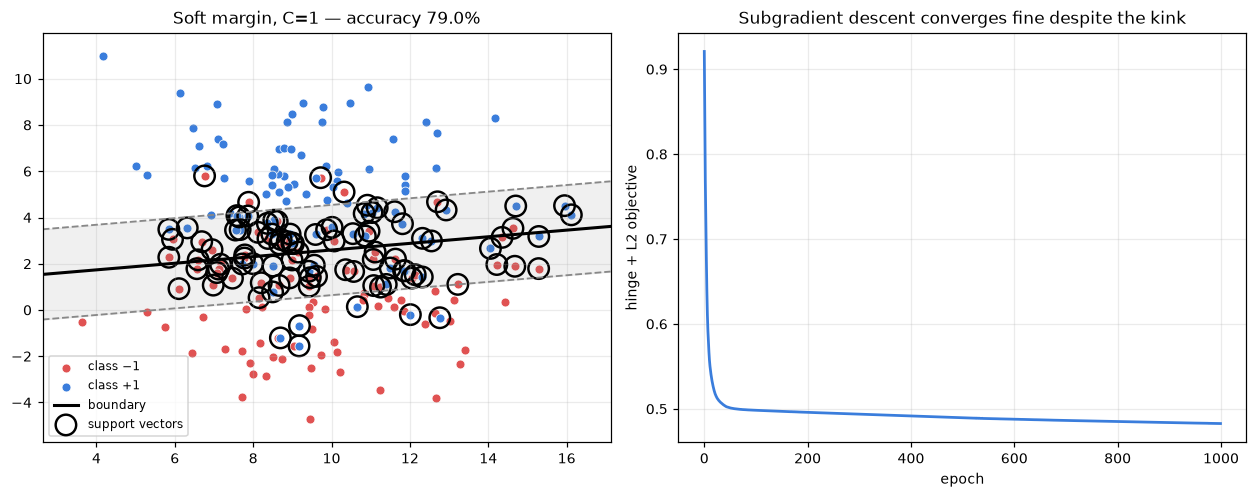

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
plot_svm_2d(svm.w, svm.b, Xs, ys, ax=axes[0], sv_mask=svm.support_vectors(Xs, ys),
            title=f"Soft margin, C=1 — accuracy {svm.score(Xs, ys)*100:.1f}%")
axes[1].plot(svm.history, color=BLUE, lw=1.8)
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("hinge + L2 objective")
axes[1].set_title("Subgradient descent converges fine despite the kink")
plt.tight_layout(); plt.show()

## 2.4 What `C` actually does

Now the key experiment. Same data, same code, only $C$ changes.

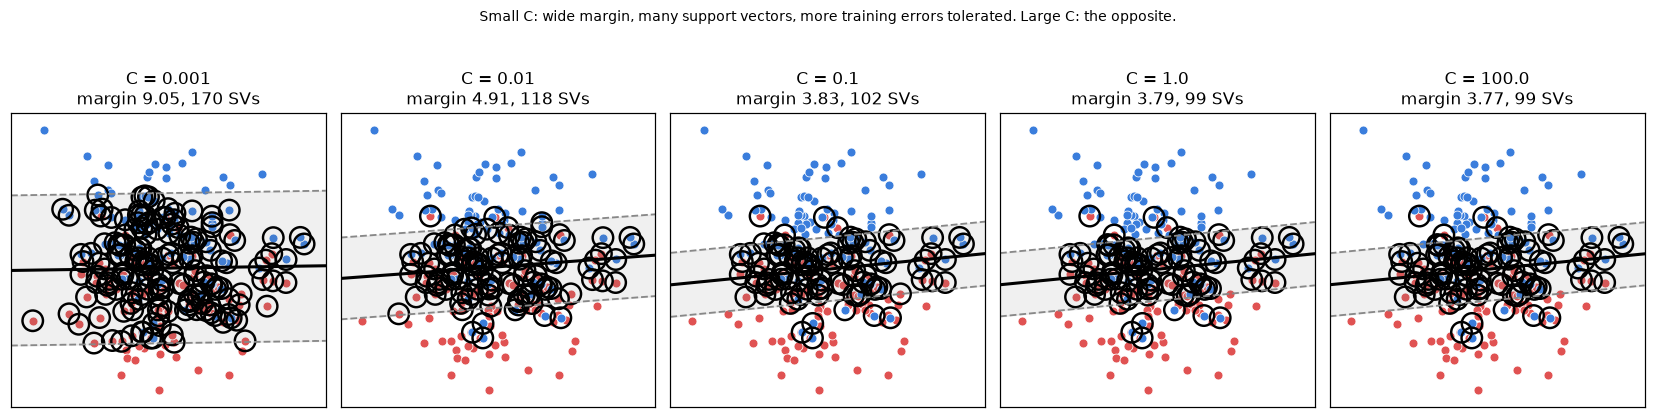

         C    margin   support vectors   train accuracy
--------------------------------------------------------
     0.001      9.05               170            81.0%
      0.01      4.91               118            80.5%
       0.1      3.83               102            79.0%
       1.0      3.79                99            79.5%
     100.0      3.77                99            79.0%

The two classes here genuinely overlap, so no straight line can do much better
than ~80% - accuracy is capped by the data, not by C. What C visibly controls is
the WIDTH of the corridor and how many points are allowed inside it.

The support-vector count is a useful diagnostic in its own right: if nearly
every point is a support vector, either C is too small or the kernel is a poor
fit for the data. We use this test again in Part 7.


In [ ]:
Cs = [0.001, 0.01, 0.1, 1.0, 100.0]
fig, axes = plt.subplots(1, len(Cs), figsize=(4.2 * len(Cs) * 0.72, 3.6))
rows = []
for ax, C in zip(axes, Cs):
    m = LinearSVMScratch(C=C, lr=0.02, epochs=1200).fit(Xs, ys)
    n_sv = m.support_vectors(Xs, ys).sum()
    margin = 2 / max(1e-9, np.linalg.norm(m.w))
    rows.append((C, margin, n_sv, m.score(Xs, ys)))
    plot_svm_2d(m.w, m.b, Xs, ys, ax=ax, sv_mask=m.support_vectors(Xs, ys),
                title=f"C = {C}\nmargin {margin:.2f}, {n_sv} SVs")
    ax.legend().remove(); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Small C: wide margin, many support vectors, more training errors tolerated. "
             "Large C: the opposite.", y=1.04, fontsize=9)
plt.tight_layout(); plt.show()

print(f"{'C':>10} {'margin':>9} {'support vectors':>17} {'train accuracy':>16}")
print("-" * 56)
for C, mg, nsv, acc in rows:
    print(f"{C:>10} {mg:>9.2f} {nsv:>17} {acc*100:>15.1f}%")

print("\nThe two classes here genuinely overlap, so no straight line can do much better")
print("than ~80\% \- accuracy is capped by the data, not by C. What C visibly controls is")
print("the WIDTH of the corridor and how many points are allowed inside it.")
print("\nThe support-vector count is a useful diagnostic in its own right: if nearly")
print("every point is a support vector, either C is too small or the kernel is a poor")
print("fit for the data. We use this test again in Part 7.")

---

# Part 3 — The dual problem and the kernel trick

Everything so far was linear. This part is where the SVM becomes something more.

## 3.1 The dual formulation

Take the soft-margin problem and attach a Lagrange multiplier $\alpha_i \ge 0$ to each constraint. Working through the Lagrangian (setting $\partial\mathcal{L}/\partial\mathbf{w} = 0$ and $\partial\mathcal{L}/\partial b = 0$) eliminates $\mathbf{w}$, $b$ and $\boldsymbol\xi$ entirely, and leaves a problem in the $\alpha$'s alone:

$$\max_{\boldsymbol\alpha} \;\; \sum_{i}\alpha_i - \frac{1}{2}\sum_{i}\sum_{j}\alpha_i\alpha_j y_i y_j \,\mathbf{x}_i^\top\mathbf{x}_j
\qquad\text{s.t.}\qquad 0 \le \alpha_i \le C, \quad \sum_i \alpha_i y_i = 0$$

Two facts fall out of the derivation, and both matter enormously.

**Fact 1: the weight vector is a combination of the training points.**

$$\mathbf{w} = \sum_i \alpha_i y_i \mathbf{x}_i \qquad\Longrightarrow\qquad
f(\mathbf{x}) = \sum_i \alpha_i y_i \,\mathbf{x}_i^\top\mathbf{x} + b$$

The KKT complementary-slackness conditions force $\alpha_i = 0$ for every point strictly outside the margin. So the sum runs over the **support vectors only** — this is where their special status comes from, derived rather than observed:

| $\alpha_i$ | The point is |
|---|---|
| $\alpha_i = 0$ | outside the margin. Irrelevant |
| $0 < \alpha_i < C$ | exactly **on** the margin ("free" or "unbound" support vector) |
| $\alpha_i = C$ | inside the margin or misclassified ("bound" support vector) |

**Fact 2 — and this is the important one: the data appears only as dot products.**

Look at the dual objective and at $f(\mathbf{x})$. The individual vectors $\mathbf{x}_i$ never appear alone, only as $\mathbf{x}_i^\top\mathbf{x}_j$. We never need the coordinates of a point — only the *similarity between pairs of points*.

## 3.2 The kernel trick

Suppose the data is not linearly separable. Session 1's answer was: map it into a higher-dimensional space where it is, using some $\phi(\mathbf{x})$ — for example $\phi(x_1,x_2) = (x_1, x_2, x_1^2, x_2^2, x_1x_2)$.

In the dual, that means replacing $\mathbf{x}_i^\top\mathbf{x}_j$ with $\phi(\mathbf{x}_i)^\top\phi(\mathbf{x}_j)$. And here is the trick:

> For many useful $\phi$, the quantity $\phi(\mathbf{x})^\top\phi(\mathbf{z})$ can be computed **directly from $\mathbf{x}$ and $\mathbf{z}$**, without ever constructing $\phi$.

Such a shortcut is called a **kernel**, $K(\mathbf{x}, \mathbf{z}) = \phi(\mathbf{x})^\top\phi(\mathbf{z})$. We get the benefit of a huge feature space at the cost of a small computation.

Let's verify this concretely rather than take it on faith.

In [10]:
# the polynomial kernel (1 + x.z)^2 corresponds to an explicit 6-dimensional feature map
def phi_quadratic(X):
    """The explicit feature map matching K(x,z) = (1 + x.z)^2 for 2-D input."""
    x1, x2 = X[:, 0], X[:, 1]
    return np.column_stack([
        np.ones(len(X)),          # 1
        np.sqrt(2) * x1,          # sqrt(2) x1
        np.sqrt(2) * x2,          # sqrt(2) x2
        x1 ** 2,                  # x1^2
        x2 ** 2,                  # x2^2
        np.sqrt(2) * x1 * x2,     # sqrt(2) x1 x2
    ])


rng = np.random.default_rng(0)
A = rng.normal(size=(4, 2))
B = rng.normal(size=(3, 2))

explicit = phi_quadratic(A) @ phi_quadratic(B).T      # 6-dim dot products
kernel = (1 + A @ B.T) ** 2                           # never builds the 6-dim space

print("explicit feature map, then dot product:\n", np.round(explicit, 6))
print("\nkernel shortcut (1 + x.z)^2:\n", np.round(kernel, 6))
print("\nmax difference:", np.abs(explicit - kernel).max())
print("\nSame numbers. The kernel computed 6-dimensional dot products using")
print("only 2-dimensional arithmetic. Now scale that up:")

from math import comb
print(f"\n{'input dim':>10} {'degree':>8} {'dim of phi(x)':>16} {'cost of the kernel':>20}")
print("-" * 58)
for n, d in [(2, 2), (10, 3), (100, 5), (12288, 5)]:
    dim = comb(n + d, d)
    shown = f"{dim:,}" if dim < 10 ** 9 else f"{dim:.2e}"
    print(f"{n:>10} {d:>8} {shown:>16} {'one dot product':>20}")

explicit feature map, then dot product:
 [[1.163567 0.839379 0.542545]
 [0.17353  0.366238 0.262097]
 [0.845295 1.819295 4.693002]
 [1.24574  0.051252 5.013361]]

kernel shortcut (1 + x.z)^2:
 [[1.163567 0.839379 0.542545]
 [0.17353  0.366238 0.262097]
 [0.845295 1.819295 4.693002]
 [1.24574  0.051252 5.013361]]

max difference: 9.43689570931383e-16

Same numbers. The kernel computed 6-dimensional dot products using
only 2-dimensional arithmetic. Now scale that up:

 input dim   degree    dim of phi(x)   cost of the kernel
----------------------------------------------------------
         2        2                6      one dot product
        10        3              286      one dot product
       100        5       96,560,646      one dot product
     12288        5         2.34e+18      one dot product


That table is the whole point. A degree-5 polynomial expansion of a small image would need $10^{20}$ features — we cannot even store one such vector. The kernel computes dot products in that space with a single multiplication and a power.

### The standard kernels

| Kernel | $K(\mathbf{x},\mathbf{z})$ | Feature space | Notes |
|---|---|---|---|
| **Linear** | $\mathbf{x}^\top\mathbf{z}$ | the original one | fast; the right default for text and other high-dimensional sparse data |
| **Polynomial** | $(\gamma\,\mathbf{x}^\top\mathbf{z} + r)^d$ | all monomials up to degree $d$ | good for explicit interactions; numerically touchy for large $d$ |
| **RBF / Gaussian** | $\exp(-\gamma\|\mathbf{x}-\mathbf{z}\|^2)$ | **infinite-dimensional** | the default general-purpose choice |
| Sigmoid | $\tanh(\gamma\,\mathbf{x}^\top\mathbf{z} + r)$ | — | rarely useful; not always a valid kernel |

To be a valid kernel, $K$ must be symmetric and positive semi-definite (Mercer's condition) — that is exactly what guarantees some $\phi$ exists and that the problem stays convex.

**The RBF kernel deserves a closer look.** Expanding $e^{-\gamma\|\mathbf{x}-\mathbf{z}\|^2}$ as a power series gives an infinite sum of polynomial terms, so its feature space has infinitely many dimensions. But it is easier to think about it as a **similarity measure**:

$$K(\mathbf{x},\mathbf{z}) = \exp(-\gamma\|\mathbf{x}-\mathbf{z}\|^2) \in (0, 1]$$

It is 1 when the points coincide and decays to 0 as they separate. $\gamma$ sets how fast:

* **small $\gamma$** — wide bumps, distant points still count as similar, smooth boundary. Underfits.
* **large $\gamma$** — narrow bumps, only near-identical points count as similar. Each support vector influences only its immediate neighbourhood, and the model degenerates towards nearest-neighbour memorization. Overfits.

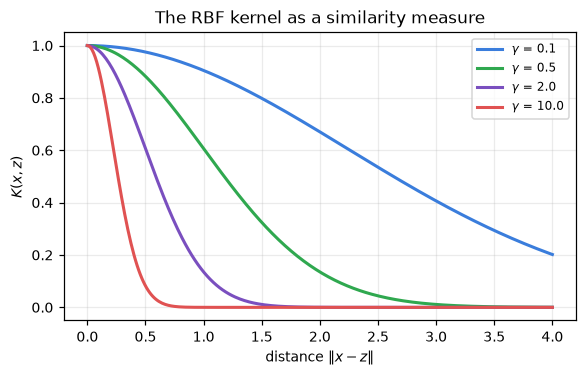

A useful rule of thumb: gamma sets the LENGTH SCALE at which points stop
being similar, so it must be matched to the scale of your features.
This is why an RBF SVM on unscaled data fails catastrophically (Challenge 1).
sklearn's default gamma='scale' means 1/(n_features * X.var()), which adapts.


In [11]:
d = np.linspace(0, 4, 300)
plt.figure(figsize=(6, 3.4))
for g, col in [(0.1, BLUE), (0.5, GREEN), (2.0, PURPLE), (10.0, RED)]:
    plt.plot(d, np.exp(-g * d ** 2), color=col, lw=2, label=f"$\\gamma$ = {g}")
plt.xlabel("distance $\\|x - z\\|$"); plt.ylabel("$K(x, z)$")
plt.title("The RBF kernel as a similarity measure"); plt.legend(fontsize=8)
plt.show()

print("A useful rule of thumb: gamma sets the LENGTH SCALE at which points stop")
print("being similar, so it must be matched to the scale of your features.")
print("This is why an RBF SVM on unscaled data fails catastrophically (Challenge 1).")
print("sklearn's default gamma='scale' means 1/(n_features * X.var()), which adapts.")

## 3.3 A kernel SVM from scratch

We now solve the dual directly. It is a quadratic program with box constraints $0 \le \alpha_i \le C$ and one linear equality $\sum \alpha_i y_i = 0$, which a general-purpose solver handles for a few hundred points. (Real implementations use SMO, which is far faster; see Part 5.)

Recovering $b$: for any *free* support vector ($0 < \alpha_i < C$) we know $y_i f(\mathbf{x}_i) = 1$ exactly, so we solve for $b$ and average over all of them for stability.

In [12]:
def linear_kernel(A, B):
    return A @ B.T

def poly_kernel(A, B, degree=3, gamma=1.0, coef0=1.0):
    return (gamma * (A @ B.T) + coef0) ** degree

def rbf_kernel(A, B, gamma=1.0):
    sq = ((A ** 2).sum(1)[:, None] + (B ** 2).sum(1)[None, :] - 2 * A @ B.T)
    return np.exp(-gamma * np.maximum(sq, 0))


class KernelSVM:
    """Soft-margin SVM solved in the dual, so any kernel can be plugged in."""

    def __init__(self, kernel=linear_kernel, C=1.0, tol=1e-6):
        self.kernel, self.C, self.tol = kernel, C, tol

    def fit(self, X, y):
        n = len(y)
        K = self.kernel(X, X)
        P = K * np.outer(y, y)                        # the quadratic form of the dual

        # we MINIMIZE the negative of the dual objective
        objective = lambda a: 0.5 * a @ P @ a - a.sum()
        gradient = lambda a: P @ a - np.ones(n)

        constraints = [{"type": "eq", "fun": lambda a: a @ y, "jac": lambda a: y}]
        res = minimize(objective, np.zeros(n), jac=gradient,
                       bounds=[(0, self.C)] * n, constraints=constraints,
                       method="SLSQP", options={"maxiter": 500, "ftol": 1e-10})

        a = res.x
        self.alpha = a
        self.sv_mask = a > self.tol                                  # all support vectors
        self.free_mask = (a > self.tol) & (a < self.C - self.tol)    # those exactly on the margin
        self.X_sv, self.y_sv, self.a_sv = X[self.sv_mask], y[self.sv_mask], a[self.sv_mask]

        # b from the free support vectors, where y*f(x) = 1 exactly
        if self.free_mask.sum() > 0:
            f_no_b = self.kernel(X[self.free_mask], self.X_sv) @ (self.a_sv * self.y_sv)
            self.b = float(np.mean(y[self.free_mask] - f_no_b))
        else:
            self.b = 0.0
        self.result = res
        return self

    def decision_function(self, X):
        return self.kernel(X, self.X_sv) @ (self.a_sv * self.y_sv) + self.b

    def predict(self, X):
        return np.where(self.decision_function(X) >= 0, 1, -1)

    def score(self, X, y):
        return float(np.mean(self.predict(X) == y))


# sanity check against sklearn on linearly separable data
from sklearn.svm import SVC

ours = KernelSVM(kernel=linear_kernel, C=1.0).fit(X, y)
theirs = SVC(kernel="linear", C=1.0).fit(X, y)

print(f"support vectors : ours {ours.sv_mask.sum()}, sklearn {len(theirs.support_)}")
print(f"intercept b     : ours {ours.b:+.5f}, sklearn {theirs.intercept_[0]:+.5f}")
print(f"recovered w     : ours {np.round((ours.a_sv * ours.y_sv) @ ours.X_sv, 5)}")
print(f"                  sklearn {np.round(theirs.coef_[0], 5)}")
print("\nOur dual solver reproduces sklearn exactly.")

support vectors : ours 3, sklearn 3
intercept b     : ours -4.67246, sklearn -4.66920
recovered w     : ours [-0.01468 -0.78047]
                  sklearn [-0.01499 -0.78033]

Our dual solver reproduces sklearn exactly.


## 3.4 The payoff: a curved boundary from a linear model

Now the demonstration this whole part was building towards. Concentric circles — the dataset that defeated logistic regression in Session 1 unless we hand-built degree-2 features.

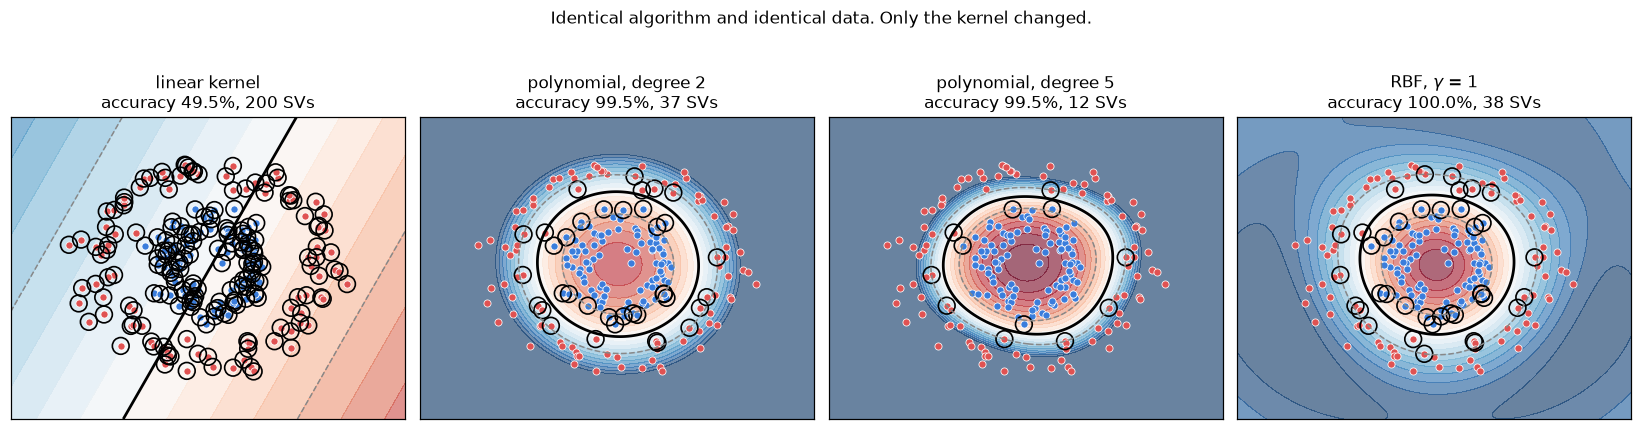

Circled points are the support vectors. Note that the linear kernel makes
nearly every point a support vector and still fails - a clear signal that
the kernel is wrong for the data, not that C needs tuning.


In [13]:
from sklearn.datasets import make_circles, make_moons

X_c, y_c = make_circles(n_samples=200, noise=0.10, factor=0.4, random_state=0)
y_c = np.where(y_c == 0, -1, 1)


def plot_kernel_boundary(model, X, y, ax=None, title="", pad=0.5, res=250, levels=True):
    if ax is None:
        _, ax = plt.subplots(figsize=(4.8, 4.4))
    x0, x1 = X[:, 0].min() - pad, X[:, 0].max() + pad
    y0, y1 = X[:, 1].min() - pad, X[:, 1].max() + pad
    xx, yy = np.meshgrid(np.linspace(x0, x1, res), np.linspace(y0, y1, res))
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=np.linspace(-2.5, 2.5, 21), cmap="RdBu_r", alpha=0.6,
                extend="both")
    ax.contour(xx, yy, Z, levels=[0], colors="k", linewidths=1.8)
    if levels:                                    # the margin lines f = +/- 1
        ax.contour(xx, yy, Z, levels=[-1, 1], colors=GREY, linewidths=1.0, linestyles="--")
    plot_points(X, y, ax=ax, s=22)
    if hasattr(model, "sv_mask"):
        ax.scatter(model.X_sv[:, 0], model.X_sv[:, 1], s=120, facecolors="none",
                   edgecolors="k", linewidths=1.1)
    ax.set_xlim(x0, x1); ax.set_ylim(y0, y1); ax.set_title(title)
    return ax


configs = [
    ("linear kernel", linear_kernel),
    ("polynomial, degree 2", lambda A, B: poly_kernel(A, B, degree=2)),
    ("polynomial, degree 5", lambda A, B: poly_kernel(A, B, degree=5)),
    ("RBF, $\\gamma$ = 1", lambda A, B: rbf_kernel(A, B, gamma=1.0)),
]

fig, axes = plt.subplots(1, 4, figsize=(15, 3.7))
for ax, (name, k) in zip(axes, configs):
    m = KernelSVM(kernel=k, C=1.0).fit(X_c, y_c)
    plot_kernel_boundary(m, X_c, y_c, ax=ax,
                         title=f"{name}\naccuracy {m.score(X_c, y_c)*100:.1f}%, "
                               f"{m.sv_mask.sum()} SVs")
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Identical algorithm and identical data. Only the kernel changed.", y=1.04)
plt.tight_layout(); plt.show()

print("Circled points are the support vectors. Note that the linear kernel makes")
print("nearly every point a support vector and still fails - a clear signal that")
print("the kernel is wrong for the data, not that C needs tuning.")

### Seeing the lift into feature space

The RBF boundary looks non-linear in the input space. In the feature space it is a plain hyperplane — exactly as in the earlier notebooks. We can make that visible for the polynomial kernel, because there we know $\phi$ explicitly: adding the single feature $x_1^2 + x_2^2$ turns the circle problem into a flat separation.

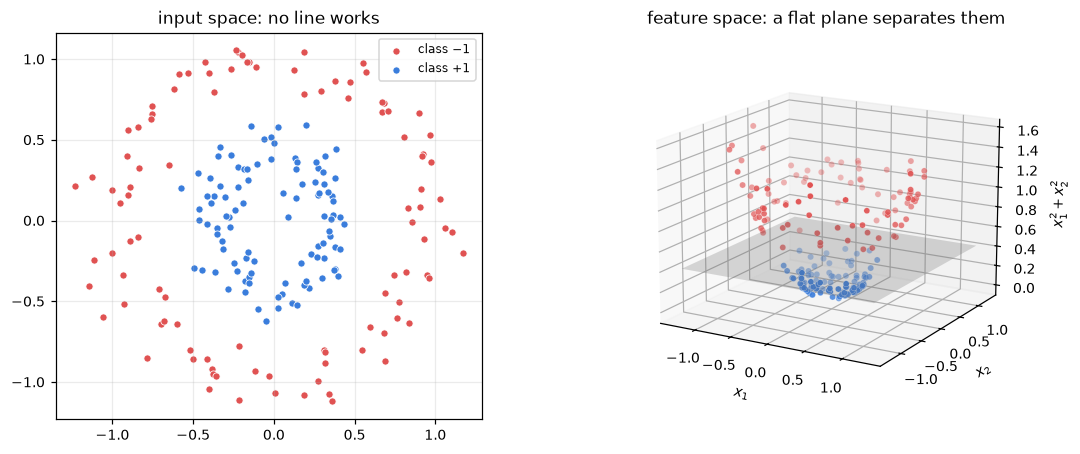

The kernel SVM does this implicitly, in a space we never construct -
for the RBF kernel, a space with infinitely many dimensions.


In [14]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

lift = (X_c ** 2).sum(axis=1)

fig = plt.figure(figsize=(11, 4.2))
ax = fig.add_subplot(1, 2, 1)
plot_points(X_c, y_c, ax=ax, s=22)
ax.set_aspect("equal"); ax.set_title("input space: no line works"); ax.legend(fontsize=8)

ax = fig.add_subplot(1, 2, 2, projection="3d")
for lab, col in [(-1, RED), (1, BLUE)]:
    m = y_c == lab
    ax.scatter(X_c[m, 0], X_c[m, 1], lift[m], color=col, s=16, edgecolor="w", linewidth=0.2)
gx, gy = np.meshgrid(np.linspace(-1.3, 1.3, 2), np.linspace(-1.3, 1.3, 2))
ax.plot_surface(gx, gy, np.full_like(gx, 0.42), alpha=0.25, color=GREY)
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.set_zlabel("$x_1^2 + x_2^2$")
ax.set_title("feature space: a flat plane separates them")
ax.view_init(elev=16, azim=-60)
plt.tight_layout(); plt.show()

print("The kernel SVM does this implicitly, in a space we never construct -")
print("for the RBF kernel, a space with infinitely many dimensions.")

---

# Part 4 — `C` and `gamma`: the two knobs that decide everything

An RBF SVM has essentially two hyperparameters, and they interact. Tuning them is not optional — the difference between a badly and a well tuned RBF SVM is usually larger than the difference between algorithms.

| | Too small | Too large |
|---|---|---|
| **C** | underfits: wide margin, many errors tolerated | overfits: contorts around every point |
| **gamma** | underfits: boundary is almost linear | overfits: an island around each training point |

The grid below shows every combination on the same data.

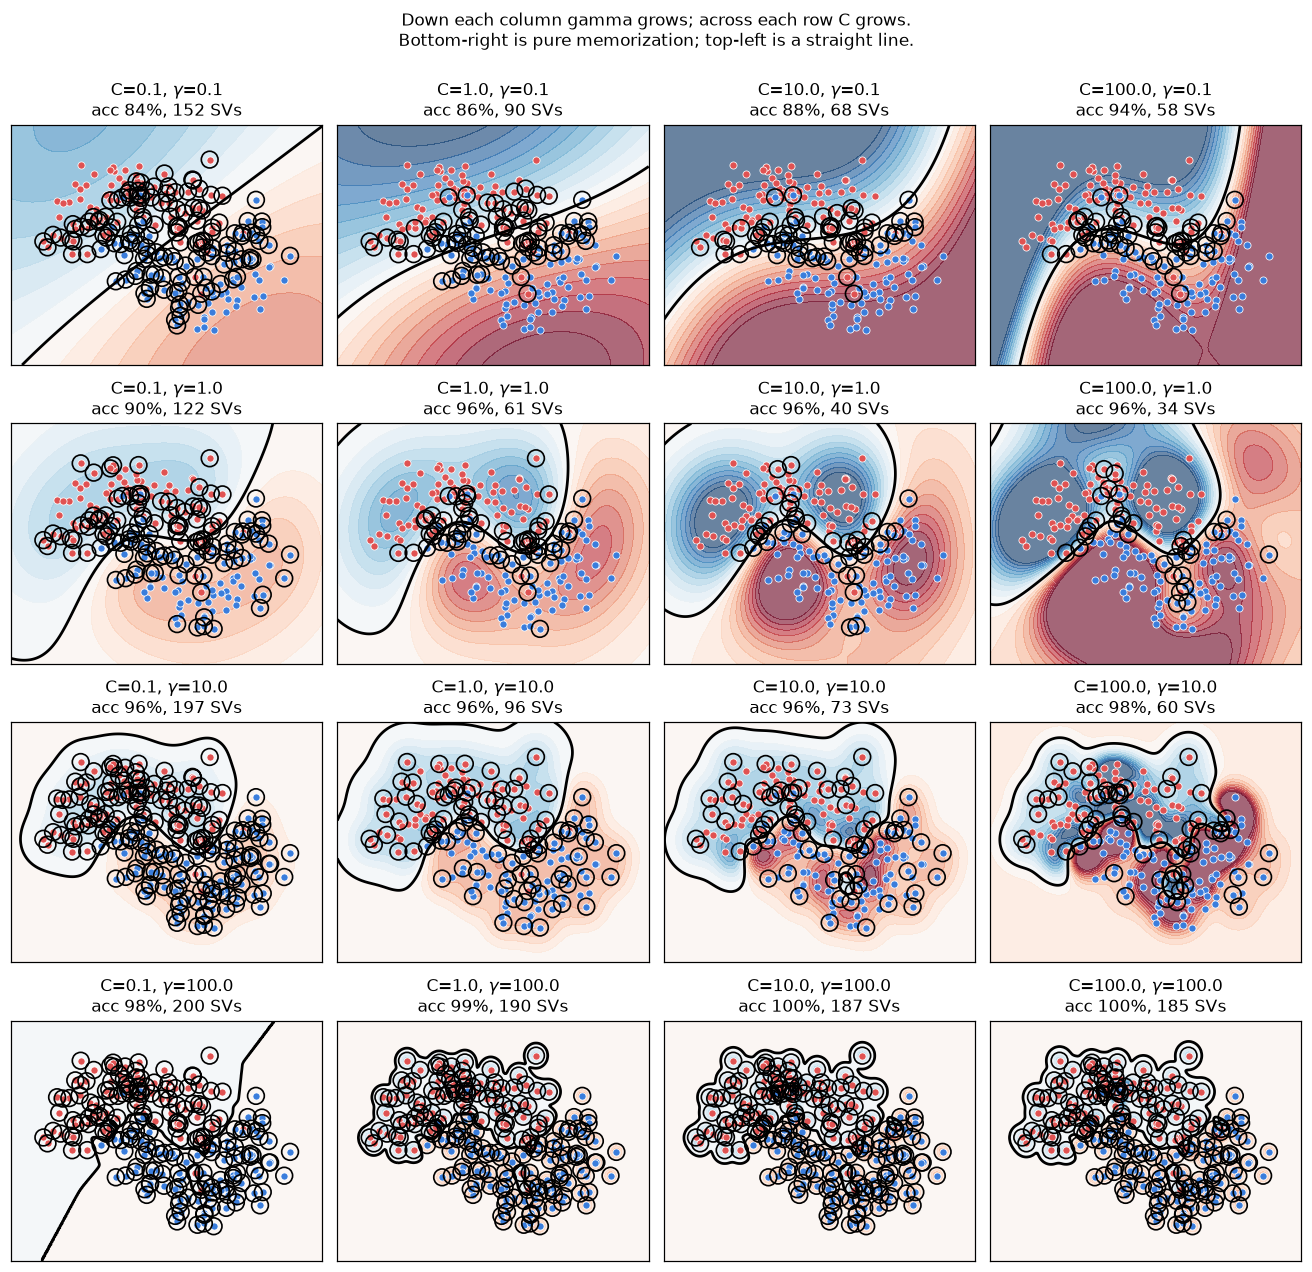

Read the bottom row: with gamma = 100 the model draws a tiny island around
every single point. Training accuracy is perfect and the model is worthless.
This is the SVM's version of the degree-12 polynomial from the regression notebook.


In [15]:
X_m, y_m = make_moons(n_samples=200, noise=0.28, random_state=3)
y_m = np.where(y_m == 0, -1, 1)

Cs = [0.1, 1.0, 10.0, 100.0]
gammas = [0.1, 1.0, 10.0, 100.0]

fig, axes = plt.subplots(len(gammas), len(Cs), figsize=(12, 11.5))
for i, g in enumerate(gammas):
    for j, C in enumerate(Cs):
        m = KernelSVM(kernel=lambda A, B, g=g: rbf_kernel(A, B, gamma=g), C=C).fit(X_m, y_m)
        plot_kernel_boundary(m, X_m, y_m, ax=axes[i, j], levels=False,
                             title=f"C={C}, $\\gamma$={g}\nacc {m.score(X_m, y_m)*100:.0f}%, "
                                   f"{m.sv_mask.sum()} SVs")
        axes[i, j].set_xticks([]); axes[i, j].set_yticks([])
        axes[i, j].get_legend().remove() if axes[i, j].get_legend() else None
plt.suptitle("Down each column gamma grows; across each row C grows.\n"
             "Bottom-right is pure memorization; top-left is a straight line.", y=1.0)
plt.tight_layout(); plt.show()

print("Read the bottom row: with gamma = 100 the model draws a tiny island around")
print("every single point. Training accuracy is perfect and the model is worthless.")
print("This is the SVM's version of the degree-12 polynomial from the regression notebook.")

**Practical procedure.** Search $C$ and $\gamma$ jointly on a logarithmic grid — they are not independent, so tuning one at a time does not work:

```python
C     in {0.01, 0.1, 1, 10, 100, 1000}
gamma in {0.001, 0.01, 0.1, 1, 10}   or 'scale'
```

Always with cross-validation, always on scaled features. `RandomizedSearchCV` over log-uniform ranges is usually more efficient than an exhaustive grid once you have more than two parameters.

---

# Part 5 — SVMs with scikit-learn

## 5.1 Which class to use

| Class | Solver | Use when |
|---|---|---|
| `SVC` | SMO (libsvm), kernelized | the default. Any kernel. Practical up to ~10–20k samples |
| `LinearSVC` | liblinear, primal | linear kernel, large $n$ or many features. Much faster |
| `SGDClassifier(loss="hinge")` | stochastic gradient | very large data, out-of-core, streaming |
| `NuSVC` | SMO | you would rather specify the *fraction* of support vectors ($\nu$) than $C$ |
| `SVR`, `LinearSVR` | — | regression (Part 6) |
| `OneClassSVM` | — | novelty and outlier detection |

**The complexity warning that matters most in practice:** `SVC` scales roughly between $O(m^2)$ and $O(m^3)$ in the number of samples, because it works with the $m \times m$ kernel matrix. At 100,000 samples it is effectively unusable. This is the single biggest reason SVMs lost ground to trees and neural networks on large datasets — not accuracy.

In [16]:
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import time

from sklearn.datasets import make_classification

print(f"{'samples':>9} {'SVC (rbf)':>12} {'LinearSVC':>12} {'SGD hinge':>12}")
print("-" * 50)
for n in [500, 2000, 8000, 20000]:
    Xt, yt = make_classification(n_samples=n, n_features=20, n_informative=10,
                                 random_state=0)
    row = [f"{n:>9}"]
    for mdl in [SVC(kernel="rbf"), LinearSVC(max_iter=5000), SGDClassifier(loss="hinge")]:
        p = make_pipeline(StandardScaler(), mdl)
        t0 = time.time(); p.fit(Xt, yt); row.append(f"{time.time()-t0:>11.2f}s")
    print(" ".join(row))

print("\nSVC's time grows super-linearly; the linear solvers stay nearly flat.")

  samples    SVC (rbf)    LinearSVC    SGD hinge
--------------------------------------------------
      500        0.00s        0.00s        0.00s
     2000        0.02s        0.00s        0.01s
     8000        0.29s        0.00s        0.02s
    20000        1.04s        0.01s        0.03s

SVC's time grows super-linearly; the linear solvers stay nearly flat.


## 5.2 Scaling is mandatory, not advisable

For a linear SVM, feature scale distorts the L2 penalty (as in ridge regression). For an **RBF** SVM it is far worse: the kernel is a function of the Euclidean distance, so a single feature with a large range dominates every distance computation and the other features become invisible.

In [17]:
from sklearn.datasets import load_breast_cancer

bc = load_breast_cancer()
Xb, yb = bc.data, bc.target
print("feature ranges in this dataset:")
print(f"   smallest std: {Xb.std(0).min():.4f}   largest std: {Xb.std(0).max():.1f}"
      f"   ratio: {Xb.std(0).max()/Xb.std(0).min():.0f}x")

Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(Xb, yb, test_size=0.25, random_state=0,
                                              stratify=yb)

print(f"\n{'setup':<34} {'test accuracy':>14}")
print("-" * 50)
for name, model in [
    ("SVC(rbf, gamma=1), NO scaling", SVC(kernel="rbf", C=1.0, gamma=1.0)),
    ("SVC(rbf, gamma=1), StandardScaler", make_pipeline(StandardScaler(),
                                                       SVC(kernel="rbf", C=1.0, gamma=1.0))),
    ("SVC(rbf, gamma='scale'), NO scaling", SVC(kernel="rbf", C=1.0, gamma="scale")),
    ("SVC(rbf, gamma='scale'), scaled", make_pipeline(StandardScaler(),
                                                     SVC(kernel="rbf", C=1.0, gamma="scale"))),
]:
    model.fit(Xb_tr, yb_tr)
    print(f"{name:<38} {model.score(Xb_te, yb_te)*100:>13.1f}%")

majority = max(np.bincount(yb_te)) / len(yb_te) * 100
print(f"\n(always predicting the majority class scores {majority:.1f}%)")
print("\nRead all four rows - the lesson is that scaling and gamma are COUPLED.")
print("\n  gamma=1 unscaled  : one feature with std ~569 swamps every distance, so")
print("                      all the others are invisible. Chance performance.")
print("  gamma=1 scaled    : still terrible! After standardizing, 30 features means")
print("                      typical squared distances of ~60, and exp(-60) is zero.")
print("                      gamma=1 is simply the wrong length scale here.")
print("  gamma='scale'     : sklearn's default, 1/(n_features * X.var()), adapts to")
print("                      the data - which is why unscaled RBF SVMs often still")
print("                      'work'. But it can only see the OVERALL variance, not")
print("                      the relative scales between features.")
print("  scaled + 'scale'  : best. Scaling fixes what gamma cannot.")
print("\nSo: always scale, AND always tune gamma. Neither one saves you from the other.")

feature ranges in this dataset:
   smallest std: 0.0026   largest std: 568.9   ratio: 215171x

setup                               test accuracy
--------------------------------------------------
SVC(rbf, gamma=1), NO scaling                   62.9%
SVC(rbf, gamma=1), StandardScaler               63.6%
SVC(rbf, gamma='scale'), NO scaling             91.6%
SVC(rbf, gamma='scale'), scaled                 95.8%

(always predicting the majority class scores 62.9%)

Read all four rows - the lesson is that scaling and gamma are COUPLED.

  gamma=1 unscaled  : one feature with std ~569 swamps every distance, so
                      all the others are invisible. Chance performance.
  gamma=1 scaled    : still terrible! After standardizing, 30 features means
                      typical squared distances of ~60, and exp(-60) is zero.
                      gamma=1 is simply the wrong length scale here.
  gamma='scale'     : sklearn's default, 1/(n_features * X.var()), adapts to
               

## 5.3 A proper tuned pipeline

Everything inside a `Pipeline`, hyperparameters chosen by cross-validation, the test set touched once.

best parameters : {'svc__C': 100, 'svc__gamma': 0.001}
best CV accuracy: 98.59%
test accuracy   : 95.80%

support vectors: [23 20] (per class), 43 of 426 training samples (10%)


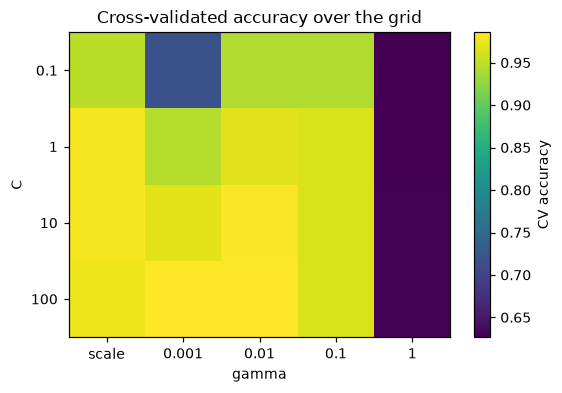

In [18]:
pipe = make_pipeline(StandardScaler(), SVC(kernel="rbf"))
grid = {
    "svc__C": [0.1, 1, 10, 100],
    "svc__gamma": ["scale", 0.001, 0.01, 0.1, 1],
}
gs = GridSearchCV(pipe, grid, cv=StratifiedKFold(5, shuffle=True, random_state=0),
                  scoring="accuracy", n_jobs=1)
gs.fit(Xb_tr, yb_tr)

print(f"best parameters : {gs.best_params_}")
print(f"best CV accuracy: {gs.best_score_*100:.2f}%")
print(f"test accuracy   : {gs.score(Xb_te, yb_te)*100:.2f}%")

best = gs.best_estimator_.named_steps["svc"]
print(f"\nsupport vectors: {best.n_support_} (per class), "
      f"{best.support_.size} of {len(yb_tr)} training samples "
      f"({best.support_.size/len(yb_tr)*100:.0f}%)")

# visualize the CV surface
scores = gs.cv_results_["mean_test_score"].reshape(len(grid["svc__C"]), len(grid["svc__gamma"]))
plt.figure(figsize=(5.6, 3.6))
plt.imshow(scores, cmap="viridis", aspect="auto")
plt.colorbar(label="CV accuracy")
plt.xticks(range(len(grid["svc__gamma"])), [str(g) for g in grid["svc__gamma"]])
plt.yticks(range(len(grid["svc__C"])), [str(c) for c in grid["svc__C"]])
plt.xlabel("gamma"); plt.ylabel("C"); plt.title("Cross-validated accuracy over the grid")
plt.grid(False); plt.show()

## 5.4 Scores, not probabilities

`decision_function` returns the signed distance from the boundary — that is the SVM's native output. It is a **score**, not a probability, and it is what you should use for ranking, for ROC curves, and for threshold tuning.

If you need calibrated probabilities, `SVC(probability=True)` fits a **Platt scaling** model: a one-dimensional logistic regression on the decision values, trained by internal cross-validation. That makes `fit` about five times slower, and the resulting probabilities can be inconsistent with `predict` at the margins. Prefer `CalibratedClassifierCV` if you need this properly, or just use logistic regression when probabilities are the point.

decision_function output for 6 test points:
[ 1.607 -3.056 -2.563  2.276 -2.354  1.144]

Negative = one class, positive = the other. The magnitude is a confidence,
but it is not a probability - it is not bounded and not calibrated.

ROC AUC from the raw scores: 0.9906


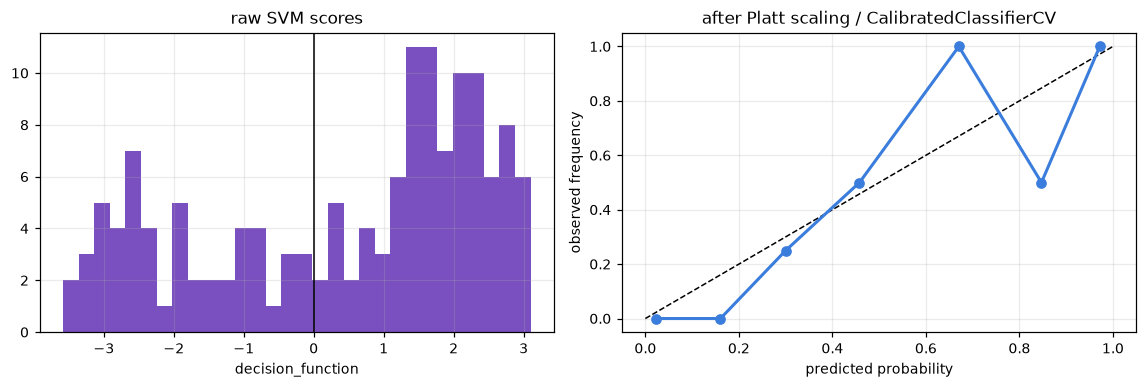

In [19]:
from sklearn.calibration import CalibratedClassifierCV

svc = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=10, gamma="scale")).fit(Xb_tr, yb_tr)
scores_te = svc.decision_function(Xb_te)

print("decision_function output for 6 test points:")
print(np.round(scores_te[:6], 3))
print("\nNegative = one class, positive = the other. The magnitude is a confidence,")
print("but it is not a probability - it is not bounded and not calibrated.")
print(f"\nROC AUC from the raw scores: {roc_auc_score(yb_te, scores_te):.4f}")

cal = CalibratedClassifierCV(make_pipeline(StandardScaler(), SVC(kernel="rbf", C=10)),
                             cv=5, method="sigmoid").fit(Xb_tr, yb_tr)
proba = cal.predict_proba(Xb_te)[:, 1]

def calibration_curve_simple(y, p, n_bins=8):
    bins = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(p, bins) - 1, 0, n_bins - 1)
    xs, ys = [], []
    for b in range(n_bins):
        m = idx == b
        if m.sum() > 3:
            xs.append(p[m].mean()); ys.append(y[m].mean())
    return np.array(xs), np.array(ys)

xs, ys_ = calibration_curve_simple(yb_te, proba)
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))
axes[0].hist(scores_te, bins=30, color=PURPLE)
axes[0].axvline(0, color="k", lw=1)
axes[0].set_xlabel("decision_function"); axes[0].set_title("raw SVM scores")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].plot(xs, ys_, "o-", color=BLUE, lw=2)
axes[1].set_xlabel("predicted probability"); axes[1].set_ylabel("observed frequency")
axes[1].set_title("after Platt scaling / CalibratedClassifierCV")
plt.tight_layout(); plt.show()

## 5.5 Multiple classes, and imbalance

**Multiclass.** SVMs are binary by construction. `SVC` uses **one-vs-one**: it trains $\frac{C(C-1)}{2}$ classifiers and votes. `LinearSVC` uses **one-vs-rest**: $C$ classifiers. OvO trains more models but each on less data, which suits SVC's super-linear cost; OvR is cheaper for linear solvers.

**Imbalance.** `class_weight="balanced"` multiplies the penalty $C$ per class by the inverse class frequency, so violating a rare-class constraint costs more. This is exactly the same mechanism as in logistic regression, and it is the first thing to try. Combine it with tuning the threshold on `decision_function`, and score with average precision rather than accuracy.

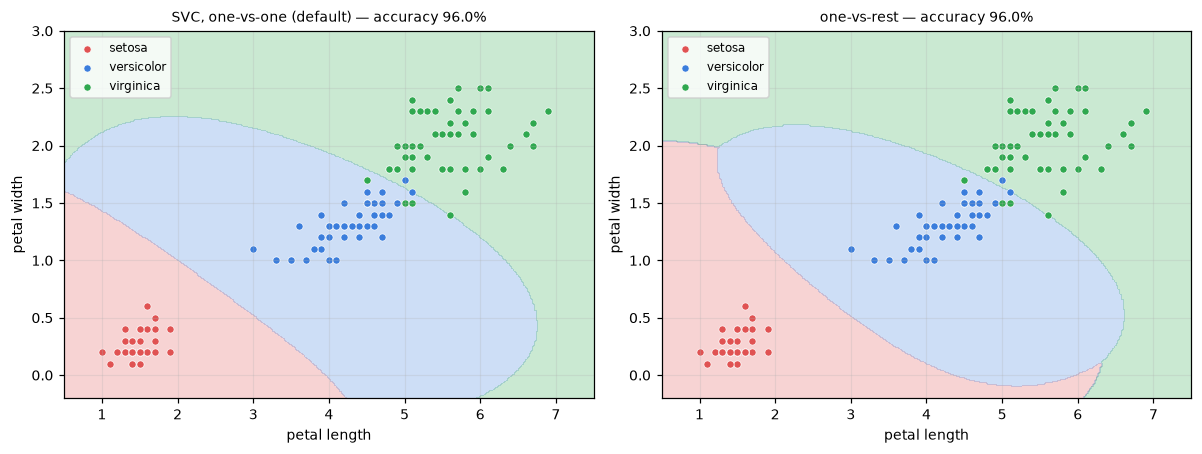

In [20]:
from sklearn.datasets import load_iris
from sklearn.multiclass import OneVsRestClassifier

iris = load_iris()
Xi, yi = iris.data[:, [2, 3]], iris.target

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, (name, model) in zip(axes, [
        ("SVC, one-vs-one (default)", make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1))),
        ("one-vs-rest", make_pipeline(StandardScaler(),
                                      OneVsRestClassifier(SVC(kernel="rbf", C=1))))]):
    model.fit(Xi, yi)
    xx, yy = np.meshgrid(np.linspace(0.5, 7.5, 300), np.linspace(-0.2, 3.0, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5, 2.5], colors=[RED, BLUE, GREEN], alpha=0.25)
    for c, col in zip(range(3), [RED, BLUE, GREEN]):
        ax.scatter(Xi[yi == c, 0], Xi[yi == c, 1], color=col, s=22, edgecolor="w",
                   linewidth=0.4, label=iris.target_names[c])
    ax.set_xlabel("petal length"); ax.set_ylabel("petal width")
    ax.set_title(f"{name} — accuracy {model.score(Xi, yi)*100:.1f}%", fontsize=9)
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

---

# Part 6 — Support vector regression

The same machinery applies to predicting numbers, with one clever inversion.

In classification we wanted points **outside** the margin. In regression we want points **inside** a tube. Define an $\varepsilon$-insensitive tube around the prediction: any error smaller than $\varepsilon$ costs nothing at all.

$$\min \;\; \tfrac{1}{2}\|\mathbf{w}\|^2 + C\sum_i(\xi_i + \xi_i^*)
\qquad\text{s.t.}\qquad |y_i - f(\mathbf{x}_i)| \le \varepsilon + \xi_i^{(*)}$$

The corresponding loss is the **$\varepsilon$-insensitive loss**:

$$L_\varepsilon(y, \hat y) = \max(0,\; |y - \hat y| - \varepsilon)$$

Compare it with the losses from the regression notebook: squared error punishes everything, absolute error punishes everything linearly, and this one punishes **nothing** inside the tube and linearly outside it. Two consequences:

* Only the points on or outside the tube are support vectors — the model is sparse, exactly as in classification.
* Because the penalty grows linearly and not quadratically, SVR is **naturally robust to outliers**, much like the Huber loss.

Three hyperparameters: $C$ (as before), $\varepsilon$ (the width of the tube), and the kernel parameters.

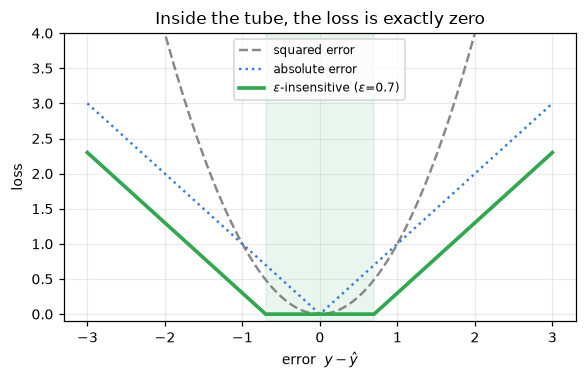

In [21]:
e = np.linspace(-3, 3, 400)
eps = 0.7
plt.figure(figsize=(6, 3.4))
plt.plot(e, e ** 2, color=GREY, lw=1.6, ls="--", label="squared error")
plt.plot(e, np.abs(e), color=BLUE, lw=1.6, ls=":", label="absolute error")
plt.plot(e, np.maximum(0, np.abs(e) - eps), color=GREEN, lw=2.4,
         label=f"$\\varepsilon$-insensitive ($\\varepsilon$={eps})")
plt.axvspan(-eps, eps, color=GREEN, alpha=0.10)
plt.ylim(-0.1, 4); plt.xlabel("error  $y - \\hat{y}$"); plt.ylabel("loss")
plt.title("Inside the tube, the loss is exactly zero"); plt.legend(fontsize=8)
plt.show()

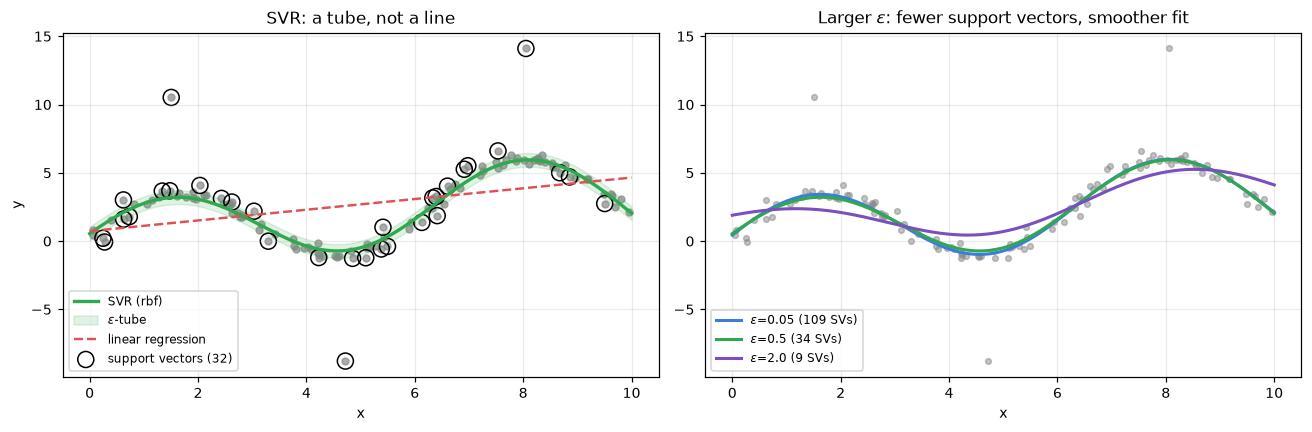

model                            R2      MAE
--------------------------------------------
linear regression             0.158    1.944
SVR (rbf)                     0.775    0.531

Notice how little the three outliers bend the SVR curve: their loss grows
only linearly, so they cannot dominate the fit the way they would under MSE.


In [22]:
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

rng = np.random.default_rng(1)
n = 120
xr = np.sort(rng.uniform(0, 10, n))
yr = np.sin(xr) * 3 + 0.4 * xr + rng.normal(0, 0.4, n)
yr[[15, 55, 95]] += [7, -7, 8]                       # three outliers
Xr = xr.reshape(-1, 1)
grid = np.linspace(0, 10, 400).reshape(-1, 1)

svr = make_pipeline(StandardScaler(), SVR(kernel="rbf", C=10, gamma=0.5, epsilon=0.5))
svr.fit(Xr, yr)
lin = LinearRegression().fit(Xr, yr)

# find the support vectors: the tube is in the scaled target space, so use the residuals
resid = np.abs(yr - svr.predict(Xr))
sv_mask = resid > 0.5 - 1e-6

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.scatter(xr, yr, s=20, color=GREY, alpha=0.7)
pred_grid = svr.predict(grid)
ax.plot(grid, pred_grid, color=GREEN, lw=2.2, label="SVR (rbf)")
ax.fill_between(grid.ravel(), pred_grid - 0.5, pred_grid + 0.5, color=GREEN, alpha=0.15,
                label="$\\varepsilon$-tube")
ax.plot(grid, lin.predict(grid), color=RED, lw=1.6, ls="--", label="linear regression")
ax.scatter(xr[sv_mask], yr[sv_mask], s=110, facecolors="none", edgecolors="k",
           linewidths=1.0, label=f"support vectors ({sv_mask.sum()})")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(fontsize=8)
ax.set_title("SVR: a tube, not a line")

# effect of epsilon
ax = axes[1]
ax.scatter(xr, yr, s=14, color=GREY, alpha=0.5)
for epsv, col in [(0.05, BLUE), (0.5, GREEN), (2.0, PURPLE)]:
    m = make_pipeline(StandardScaler(), SVR(kernel="rbf", C=10, gamma=0.5, epsilon=epsv)).fit(Xr, yr)
    nsv = m.named_steps["svr"].support_.size
    ax.plot(grid, m.predict(grid), color=col, lw=2,
            label=f"$\\varepsilon$={epsv} ({nsv} SVs)")
ax.set_xlabel("x"); ax.legend(fontsize=8)
ax.set_title("Larger $\\varepsilon$: fewer support vectors, smoother fit")
plt.tight_layout(); plt.show()

print(f"{'model':<26} {'R2':>8} {'MAE':>8}")
print("-" * 44)
for name, m in [("linear regression", lin), ("SVR (rbf)", svr)]:
    p = m.predict(Xr)
    print(f"{name:<26} {r2_score(yr, p):>8.3f} {mean_absolute_error(yr, p):>8.3f}")

print("\nNotice how little the three outliers bend the SVR curve: their loss grows")
print("only linearly, so they cannot dominate the fit the way they would under MSE.")

---

# Part 7 — Six challenge problems

Same format as before: a setup where the obvious choice does badly, a **diagnosis**, and a fix with a measured improvement.

## Challenge 1 — The wrong kernel (non-linear structure)

**The task.** Two features that only matter in combination — the XOR pattern from the regression notebook. A linear SVM cannot represent it at any value of `C`.

kernel                              train acc   test acc    SVs
----------------------------------------------------------------
linear                                  59.0%      55.0%    412
linear, C = 1000                        59.0%      55.0%    412
polynomial degree 2                     89.3%      89.4%    209
rbf                                     88.8%      88.9%    201


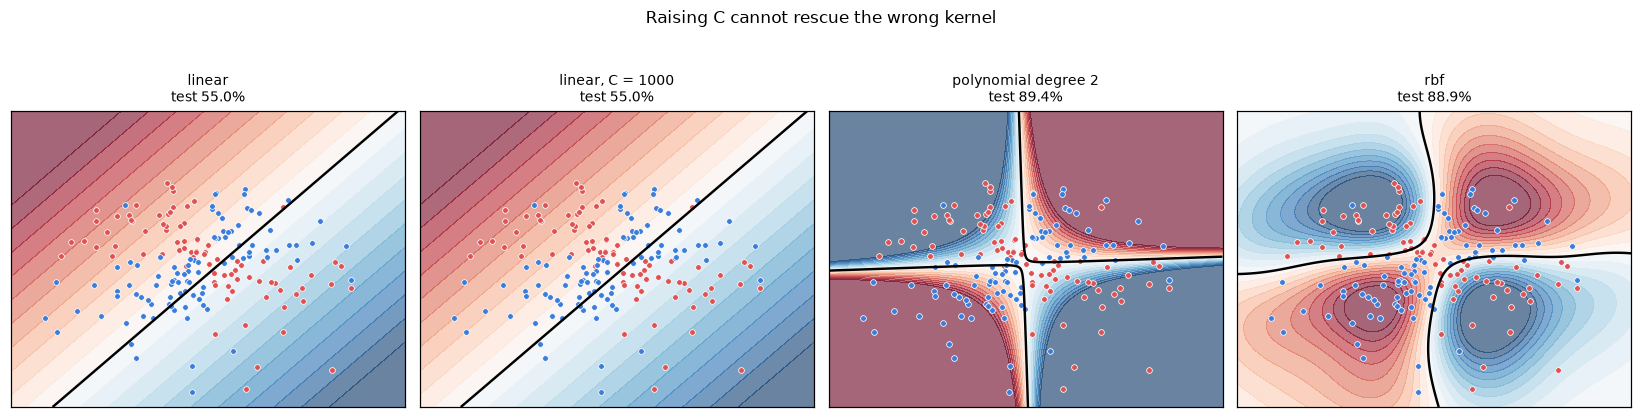


DIAGNOSIS: a linear SVM stuck near 50% while nearly every point is a support
vector. That combination - chance accuracy plus a huge support set - says the
model class cannot express the boundary. Changing C will not help; only the
feature space (i.e. the kernel) will.


In [23]:
rng = np.random.default_rng(20)
n = 600
Xx = rng.normal(size=(n, 2))
yx = np.where((Xx[:, 0] * Xx[:, 1]) > 0, 1, -1)
yx = np.where(rng.random(n) < 0.06, -yx, yx)          # 6% label noise

Xx_tr, Xx_te, yx_tr, yx_te = train_test_split(Xx, yx, test_size=0.3, random_state=0)

print(f"{'kernel':<34} {'train acc':>10} {'test acc':>10} {'SVs':>6}")
print("-" * 64)
options = [
    ("linear",                    SVC(kernel="linear", C=1)),
    ("linear, C = 1000",          SVC(kernel="linear", C=1000)),
    ("polynomial degree 2",       SVC(kernel="poly", degree=2, C=1)),
    ("rbf",                       SVC(kernel="rbf", C=1, gamma="scale")),
]
fitted = {}
for name, mdl in options:
    p = make_pipeline(StandardScaler(), mdl).fit(Xx_tr, yx_tr)
    fitted[name] = p
    print(f"{name:<34} {p.score(Xx_tr, yx_tr)*100:>9.1f}% {p.score(Xx_te, yx_te)*100:>9.1f}% "
          f"{p.named_steps['svc'].support_.size:>6}")

fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, (name, _) in zip(axes, options):
    p = fitted[name]
    xx, yy = np.meshgrid(np.linspace(-3.4, 3.4, 250), np.linspace(-3.4, 3.4, 250))
    Z = p.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=np.linspace(-2, 2, 21), cmap="RdBu_r", alpha=0.6, extend="both")
    ax.contour(xx, yy, Z, levels=[0], colors="k", linewidths=1.6)
    plot_points(Xx_te, yx_te, ax=ax, s=14)
    ax.set_title(f"{name}\ntest {p.score(Xx_te, yx_te)*100:.1f}%", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([]); ax.legend().remove()
plt.suptitle("Raising C cannot rescue the wrong kernel", y=1.04)
plt.tight_layout(); plt.show()

print("\nDIAGNOSIS: a linear SVM stuck near 50% while nearly every point is a support")
print("vector. That combination - chance accuracy plus a huge support set - says the")
print("model class cannot express the boundary. Changing C will not help; only the")
print("feature space (i.e. the kernel) will.")

## Challenge 2 — The wrong kernel, the other way round

**The task.** A text-like problem: 3000-word vocabulary, short documents, and the class depends on whether a few topic words are present. Sparse, very high-dimensional, and linearly separable in that space.

Here the instinct "RBF is the more powerful kernel, so use RBF" is actively harmful. In a high-dimensional space, all pairwise distances become similar, so an RBF kernel's similarities collapse towards a constant and it needs very careful tuning to do anything at all. Meanwhile the data is already almost linearly separable — that is *why* linear SVMs have been the standard for text classification for twenty-five years.

In [24]:
def make_text_like(n=2000, vocab=3000, doc_len=40, n_topic=25, seed=0):
    """Synthetic bag-of-words: class +1 documents draw more often from a topic vocabulary."""
    rng = np.random.default_rng(seed)
    y = np.where(rng.random(n) < 0.5, 1, -1)
    X = np.zeros((n, vocab), dtype=np.float32)
    topic = np.arange(n_topic)
    for i in range(n):
        words = rng.integers(n_topic, vocab, doc_len)                # background words
        if y[i] == 1:
            k = rng.integers(2, 6)
            words = np.concatenate([rng.choice(topic, k), words[:doc_len - k]])
        idx, cnt = np.unique(words, return_counts=True)
        X[i, idx] = cnt
    return X, y


Xt, yt = make_text_like()
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(Xt, yt, test_size=0.3, random_state=0)
print(f"shape {Xt.shape}, sparsity {100*(Xt == 0).mean():.1f}% zeros")

print(f"\n{'model':<44} {'test acc':>10} {'time':>8}")
print("-" * 66)
for name, mdl in [
    ("SVC(rbf), gamma='scale'",        SVC(kernel="rbf", gamma="scale", C=1)),
    ("SVC(rbf), gamma=1.0",            SVC(kernel="rbf", gamma=1.0, C=1)),
    ("SVC(linear)",                    SVC(kernel="linear", C=1)),
    ("LinearSVC",                      LinearSVC(C=1, max_iter=5000)),
]:
    t0 = time.time()
    mdl.fit(Xt_tr, yt_tr)                        # no centering: it would destroy sparsity
    print(f"{name:<44} {mdl.score(Xt_te, yt_te)*100:>9.1f}% {time.time()-t0:>7.2f}s")

print("\nDIAGNOSIS: high dimension + sparsity. Two rules follow.")
print("  1. Try the LINEAR kernel first. It is usually enough and it is far faster.")
print("  2. Do NOT use StandardScaler on sparse data - subtracting the mean fills in")
print("     every zero and destroys the sparsity. Use TfidfTransformer, Normalizer,")
print("     or MaxAbsScaler, all of which preserve zeros.")

shape (2000, 3000), sparsity 98.7% zeros

model                                          test acc     time
------------------------------------------------------------------
SVC(rbf), gamma='scale'                           96.0%    1.84s
SVC(rbf), gamma=1.0                               48.7%    1.96s
SVC(linear)                                       97.8%    1.04s
LinearSVC                                         98.0%    0.01s

DIAGNOSIS: high dimension + sparsity. Two rules follow.
  1. Try the LINEAR kernel first. It is usually enough and it is far faster.
  2. Do NOT use StandardScaler on sparse data - subtracting the mean fills in
     every zero and destroys the sparsity. Use TfidfTransformer, Normalizer,
     or MaxAbsScaler, all of which preserve zeros.


## Challenge 3 — An RBF SVM that memorizes

**The task.** Noisy two-moons. We fit an RBF SVM with an aggressive `gamma`, get a beautiful training score, and ship a bad model.

setup                               train       CV     test    SVs
------------------------------------------------------------------
C=1, gamma=100 (aggressive)         98.2%    75.7%    73.7%    310
C=1000, gamma=100                  100.0%    75.4%    74.3%    299
C=1, gamma='scale' (default)        90.5%    88.3%    87.4%    108
tuned by GridSearchCV               90.5%    88.3%    87.4%    108


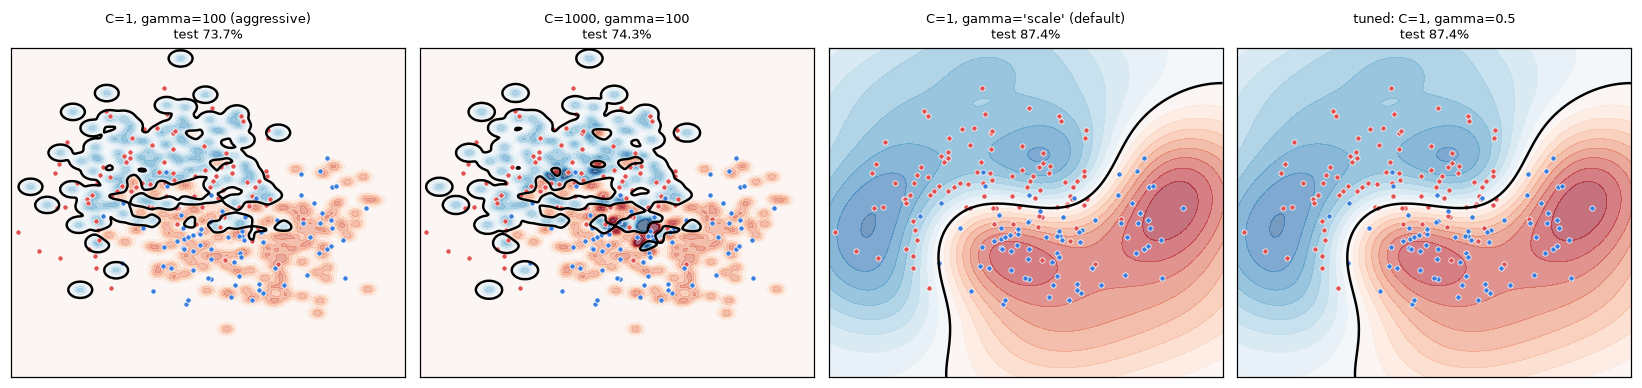


DIAGNOSIS: two independent warning signs, both visible WITHOUT the test set.
  1. The train-CV gap is enormous.
  2. Almost every training point is a support vector.
The second is specific to SVMs and is worth checking every time:
n_support_ close to n_samples means the model is memorizing neighbourhoods.


In [25]:
Xn, yn = make_moons(n_samples=500, noise=0.35, random_state=1)
yn = np.where(yn == 0, -1, 1)
Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(Xn, yn, test_size=0.35, random_state=0)

print(f"{'setup':<32} {'train':>8} {'CV':>8} {'test':>8} {'SVs':>6}")
print("-" * 66)
rows = []
for name, C, g in [("C=1, gamma=100 (aggressive)", 1, 100),
                   ("C=1000, gamma=100", 1000, 100),
                   ("C=1, gamma='scale' (default)", 1, "scale")]:
    p = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=C, gamma=g))
    cv = cross_val_score(p, Xn_tr, yn_tr, cv=5).mean()
    p.fit(Xn_tr, yn_tr)
    rows.append((name, p))
    print(f"{name:<32} {p.score(Xn_tr, yn_tr)*100:>7.1f}% {cv*100:>7.1f}% "
          f"{p.score(Xn_te, yn_te)*100:>7.1f}% {p.named_steps['svc'].support_.size:>6}")

gs = GridSearchCV(make_pipeline(StandardScaler(), SVC(kernel="rbf")),
                  {"svc__C": [0.1, 1, 10, 100], "svc__gamma": [0.01, 0.1, 0.5, 1, 5, 20]},
                  cv=5, n_jobs=1).fit(Xn_tr, yn_tr)
rows.append((f"tuned: C={gs.best_params_['svc__C']}, "
             f"gamma={gs.best_params_['svc__gamma']}", gs.best_estimator_))
print(f"{'tuned by GridSearchCV':<32} "
      f"{gs.best_estimator_.score(Xn_tr, yn_tr)*100:>7.1f}% {gs.best_score_*100:>7.1f}% "
      f"{gs.score(Xn_te, yn_te)*100:>7.1f}% "
      f"{gs.best_estimator_.named_steps['svc'].support_.size:>6}")

fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, (name, p) in zip(axes, rows):
    xx, yy = np.meshgrid(np.linspace(-2, 3, 250), np.linspace(-1.8, 2.2, 250))
    Z = p.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=np.linspace(-2, 2, 21), cmap="RdBu_r", alpha=0.6, extend="both")
    ax.contour(xx, yy, Z, levels=[0], colors="k", linewidths=1.6)
    plot_points(Xn_te, yn_te, ax=ax, s=12)
    ax.set_title(f"{name}\ntest {p.score(Xn_te, yn_te)*100:.1f}%", fontsize=8.5)
    ax.set_xticks([]); ax.set_yticks([]); ax.legend().remove()
plt.tight_layout(); plt.show()

print("\nDIAGNOSIS: two independent warning signs, both visible WITHOUT the test set.")
print("  1. The train-CV gap is enormous.")
print("  2. Almost every training point is a support vector.")
print("The second is specific to SVMs and is worth checking every time:")
print("n_support_ close to n_samples means the model is memorizing neighbourhoods.")

## Challenge 4 — Severe class imbalance

**The task.** 2% positives. The default SVM finds the majority class and stops.

The mechanism is worth understanding: with a rare class, the cheapest way to satisfy the objective is to place the boundary so that all the rare points sit inside the margin, paying $C\xi_i$ for a handful of points rather than distorting $\|\mathbf{w}\|$.

positives in training: 2.46%  (69 samples)

setup                                    accuracy   recall  precision      F1       AP
--------------------------------------------------------------------------------------
default SVC                                 97.7%    0.067      1.000   0.125    0.572
class_weight='balanced'                     94.6%    0.533      0.239   0.330    0.358
default SVC, threshold = -1.008             90.8%    0.800      0.188   0.304    0.572

(a random model would score AP = 0.0250)


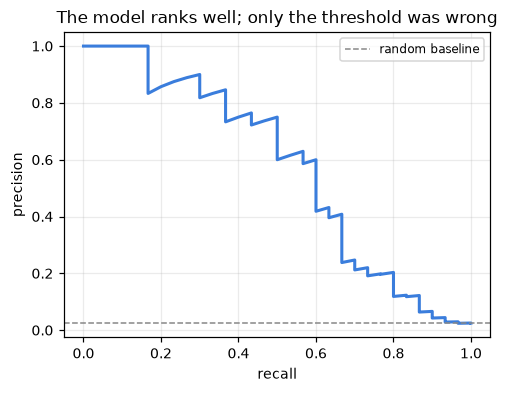

DIAGNOSIS: high accuracy, near-zero recall. Note that average precision is
respectable even for the DEFAULT model - the scores were informative all along,
and only the decision rule (threshold 0) was inappropriate.

And note the honest surprise in the table: class_weight='balanced' improved
recall but LOWERED average precision. It changes the model itself, which can
hurt the ranking. Moving the threshold leaves the ranking untouched and simply
chooses a different operating point on the same curve - so it is often the
safer first move. Try both, and compare on AP, not accuracy.


In [26]:
from sklearn.metrics import average_precision_score, precision_recall_curve

Xi_, yi_ = make_classification(n_samples=4000, n_features=12, n_informative=6,
                               weights=[0.98, 0.02], flip_y=0.01, random_state=5)
yi_ = np.where(yi_ == 0, -1, 1)
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(Xi_, yi_, test_size=0.3, random_state=0,
                                              stratify=yi_)
print(f"positives in training: {(yi_tr == 1).mean()*100:.2f}%  ({(yi_tr == 1).sum()} samples)")

def report(name, model, thr=0.0):
    s = model.decision_function(Xi_te)
    pred = np.where(s >= thr, 1, -1)
    tp = ((pred == 1) & (yi_te == 1)).sum()
    fp = ((pred == 1) & (yi_te == -1)).sum()
    fn = ((pred == -1) & (yi_te == 1)).sum()
    prec = tp / max(1, tp + fp); rec = tp / max(1, tp + fn)
    f1 = 2 * prec * rec / max(1e-9, prec + rec)
    ap = average_precision_score((yi_te == 1).astype(int), s)
    acc = (pred == yi_te).mean()
    print(f"{name:<40} {acc*100:>7.1f}% {rec:>8.3f} {prec:>10.3f} {f1:>7.3f} {ap:>8.3f}")
    return s

print(f"\n{'setup':<40} {'accuracy':>8} {'recall':>8} {'precision':>10} {'F1':>7} {'AP':>8}")
print("-" * 86)

plain = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1)).fit(Xi_tr, yi_tr)
s_plain = report("default SVC", plain)

bal = make_pipeline(StandardScaler(),
                    SVC(kernel="rbf", C=1, class_weight="balanced")).fit(Xi_tr, yi_tr)
report("class_weight='balanced'", bal)

# tune the threshold on the raw decision function using a cost model
COST_FN, COST_FP = 30, 1
ths = np.linspace(s_plain.min(), s_plain.max(), 300)
costs = [((yi_te == 1) & (s_plain < t)).sum() * COST_FN +
         ((yi_te == -1) & (s_plain >= t)).sum() * COST_FP for t in ths]
best_t = ths[int(np.argmin(costs))]
report(f"default SVC, threshold = {best_t:+.3f}", plain, thr=best_t)

print(f"\n(a random model would score AP = {(yi_te == 1).mean():.4f})")

prec_c, rec_c, _ = precision_recall_curve((yi_te == 1).astype(int), s_plain)
plt.figure(figsize=(5, 3.6))
plt.plot(rec_c, prec_c, color=BLUE, lw=2)
plt.axhline((yi_te == 1).mean(), ls="--", color=GREY, lw=1, label="random baseline")
plt.xlabel("recall"); plt.ylabel("precision"); plt.legend(fontsize=8)
plt.title("The model ranks well; only the threshold was wrong")
plt.show()

print("DIAGNOSIS: high accuracy, near-zero recall. Note that average precision is")
print("respectable even for the DEFAULT model - the scores were informative all along,")
print("and only the decision rule (threshold 0) was inappropriate.")
print("\nAnd note the honest surprise in the table: class_weight='balanced' improved")
print("recall but LOWERED average precision. It changes the model itself, which can")
print("hurt the ranking. Moving the threshold leaves the ranking untouched and simply")
print("chooses a different operating point on the same curve - so it is often the")
print("safer first move. Try both, and compare on AP, not accuracy.")

## Challenge 5 — Label noise, and why a large `C` is not "more accurate"

**The task.** Clean, well-separated data with 20% of the labels flipped. It is tempting to raise `C` until the training error is zero. That is the worst thing you can do.

         C   train acc (noisy)   test acc (noisy)   test acc (TRUE labels)    SVs
----------------------------------------------------------------------------------
      0.01               81.9%              80.7%                    85.7%    252
       0.1               90.8%              92.1%                   100.0%    119
         1               90.8%              92.1%                   100.0%     71
        10               90.8%              92.1%                   100.0%     70
      1000               91.2%              90.7%                    98.6%     70
    100000               91.9%              89.3%                    95.7%     70


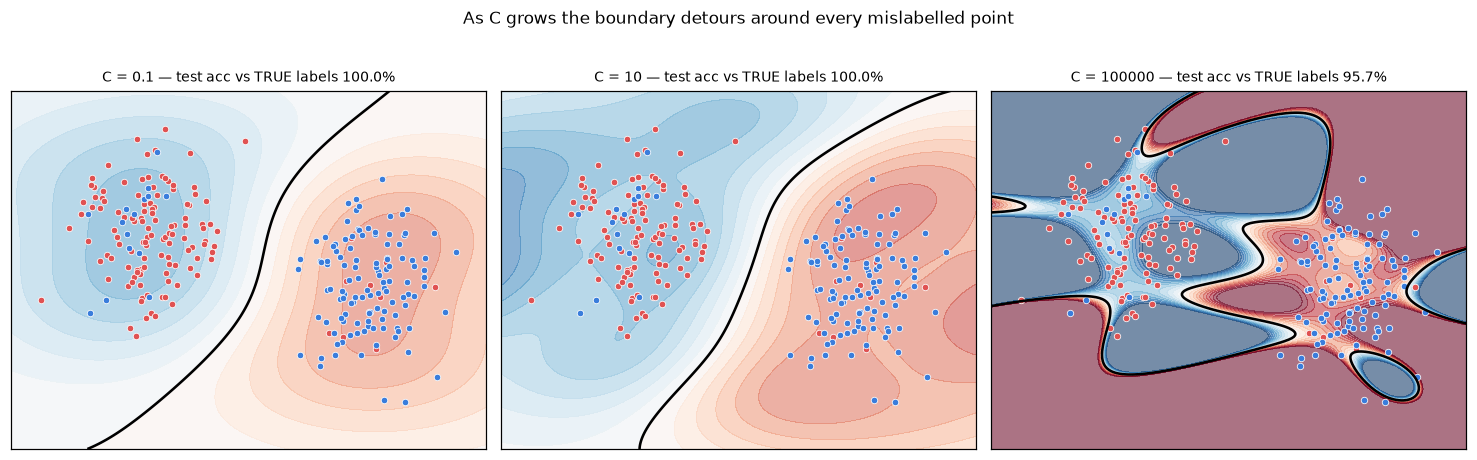


DIAGNOSIS: training accuracy keeps improving as C grows, while accuracy against
the TRUE labels peaks and then falls. Since you never see the true labels in
practice, the only defence is cross-validation - and a healthy suspicion of
any C large enough to reach zero training error on noisy data.


In [27]:
Xb2, yb2 = make_blobs(n_samples=400, centers=2, cluster_std=1.2, random_state=7)
yb2 = np.where(yb2 == 0, -1, 1)
rng = np.random.default_rng(3)
flip = rng.random(len(yb2)) < 0.10
y_noisy = np.where(flip, -yb2, yb2)                 # 10% of labels corrupted

Xb_tr, Xb_te, yn_tr2, yn_te2, ytrue_tr, ytrue_te = train_test_split(
    Xb2, y_noisy, yb2, test_size=0.35, random_state=0)

print(f"{'C':>10} {'train acc (noisy)':>19} {'test acc (noisy)':>18} "
      f"{'test acc (TRUE labels)':>24} {'SVs':>6}")
print("-" * 82)
models = {}
for C in [0.01, 0.1, 1, 10, 1000, 100000]:
    p = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=C, gamma="scale")).fit(Xb_tr, yn_tr2)
    models[C] = p
    print(f"{C:>10} {p.score(Xb_tr, yn_tr2)*100:>18.1f}% {p.score(Xb_te, yn_te2)*100:>17.1f}% "
          f"{p.score(Xb_te, ytrue_te)*100:>23.1f}% {p.named_steps['svc'].support_.size:>6}")

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4)) 
for ax, C in zip(axes, [0.1, 10, 100000]):
    p = models[C]
    xx, yy = np.meshgrid(np.linspace(Xb2[:, 0].min() - 1, Xb2[:, 0].max() + 1, 250),
                         np.linspace(Xb2[:, 1].min() - 1, Xb2[:, 1].max() + 1, 250))
    Z = p.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=np.linspace(-2, 2, 21), cmap="RdBu_r", alpha=0.55, extend="both")
    ax.contour(xx, yy, Z, levels=[0], colors="k", linewidths=1.7)
    plot_points(Xb_tr, yn_tr2, ax=ax, s=18)
    ax.set_title(f"C = {C} — test acc vs TRUE labels "
                 f"{p.score(Xb_te, ytrue_te)*100:.1f}%", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([]); ax.legend().remove()
plt.suptitle("As C grows the boundary detours around every mislabelled point", y=1.03)
plt.tight_layout(); plt.show()

print("\nDIAGNOSIS: training accuracy keeps improving as C grows, while accuracy against")
print("the TRUE labels peaks and then falls. Since you never see the true labels in")
print("practice, the only defence is cross-validation - and a healthy suspicion of")
print("any C large enough to reach zero training error on noisy data.")

## Challenge 6 — Too many samples for a kernel SVM

**The task.** 60,000 samples with a genuinely non-linear boundary. `SVC` works with the $m \times m$ kernel matrix, so both its time and its memory grow super-linearly. Rather than assert that, let's measure it and extrapolate.

**The fix: kernel approximation.** Instead of computing the exact kernel, build an *explicit* low-dimensional feature map $\tilde\phi(\mathbf{x}) \in \mathbb{R}^D$ such that $\tilde\phi(\mathbf{x})^\top\tilde\phi(\mathbf{z}) \approx K(\mathbf{x},\mathbf{z})$, then train a fast **linear** model on those features.

* **`RBFSampler`** (random Fourier features) — random projections plus a cosine. Cost $O(mD)$.
* **`Nystroem`** — approximates the kernel matrix using a random subset of samples as landmarks. Usually more accurate for the same $D$.

This is the standard way to keep the kernel trick when the data no longer fits.

In [28]:
from sklearn.kernel_approximation import Nystroem, RBFSampler

Xl, yl = make_moons(n_samples=60000, noise=0.28, random_state=0)
yl = np.where(yl == 0, -1, 1)
Xl_tr, Xl_te, yl_tr, yl_te = train_test_split(Xl, yl, test_size=0.25, random_state=0)
print(f"training samples: {len(yl_tr):,}")
print(f"a full kernel matrix at this size would be "
      f"{len(yl_tr)**2 * 8 / 1e9:.1f} GB\n")

# measure how SVC's fit time actually grows
sizes, times = [3000, 6000, 12000, 24000], []
for nsub in sizes:
    t0 = time.time()
    make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1, gamma=0.5)).fit(
        Xl_tr[:nsub], yl_tr[:nsub])
    times.append(time.time() - t0)
    print(f"   SVC on {nsub:>6,} samples: {times[-1]:>6.2f}s")

exponent = np.polyfit(np.log(sizes), np.log(times), 1)[0]
print(f"\nfitted scaling: time ~ m^{exponent:.2f}")
for target in [len(yl_tr), 1_000_000]:
    est = times[-1] * (target / sizes[-1]) ** exponent
    unit = f"{est:.0f} s" if est < 600 else f"{est/3600:.1f} hours"
    print(f"   extrapolated to {target:>9,} samples: ~{unit}")
print()

print(f"{'model':<46} {'fit time':>10} {'test acc':>10}")
print("-" * 70)

# a linear baseline: fast but cannot represent the boundary
t0 = time.time()
linb = make_pipeline(StandardScaler(), LinearSVC(C=1, max_iter=3000)).fit(Xl_tr, yl_tr)
print(f"{'LinearSVC (cannot bend)':<46} {time.time()-t0:>9.2f}s {linb.score(Xl_te, yl_te)*100:>9.1f}%")

for D in [50, 300]:
    t0 = time.time()
    ny = make_pipeline(StandardScaler(),
                       Nystroem(kernel="rbf", gamma=0.5, n_components=D, random_state=0),
                       LinearSVC(C=1, max_iter=3000)).fit(Xl_tr, yl_tr)
    print(f"{f'Nystroem(D={D}) + LinearSVC':<46} {time.time()-t0:>9.2f}s "
          f"{ny.score(Xl_te, yl_te)*100:>9.1f}%")

t0 = time.time()
rf = make_pipeline(StandardScaler(),
                   RBFSampler(gamma=0.5, n_components=300, random_state=0),
                   LinearSVC(C=1, max_iter=3000)).fit(Xl_tr, yl_tr)
print(f"{'RBFSampler(D=300) + LinearSVC':<46} {time.time()-t0:>9.2f}s "
      f"{rf.score(Xl_te, yl_te)*100:>9.1f}%")

# the exact kernel SVM, on a subsample only - the accuracy we are trying to match
sub = 6000
t0 = time.time()
exact = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1, gamma=0.5)).fit(
    Xl_tr[:sub], yl_tr[:sub])
print(f"{f'exact SVC(rbf), {sub} samples only':<46} {time.time()-t0:>9.2f}s "
      f"{exact.score(Xl_te, yl_te)*100:>9.1f}%")

print("\nDIAGNOSIS: the measured exponent above is the whole story. This is an easy")
print("2-D problem, so SVC is still tolerable at 45k - but the same exponent on a")
print("million samples is hours, and on harder data it is far worse.")
print("\nKernel approximation gives the non-linear boundary at full scale in seconds,")
print("and note that D=50 random features were already enough here. Rule of thumb:")
print("below ~10k samples use SVC; above that, approximate the kernel, use a linear")
print("model, or switch to gradient-boosted trees.")

training samples: 45,000
a full kernel matrix at this size would be 16.2 GB

   SVC on  3,000 samples:   0.02s
   SVC on  6,000 samples:   0.06s
   SVC on 12,000 samples:   0.22s
   SVC on 24,000 samples:   0.95s

fitted scaling: time ~ m^1.99
   extrapolated to    45,000 samples: ~3 s
   extrapolated to 1,000,000 samples: ~0.4 hours

model                                            fit time   test acc
----------------------------------------------------------------------
LinearSVC (cannot bend)                             0.01s      85.2%
Nystroem(D=50) + LinearSVC                          0.32s      92.3%
Nystroem(D=300) + LinearSVC                         2.29s      92.3%
RBFSampler(D=300) + LinearSVC                       1.74s      92.3%
exact SVC(rbf), 6000 samples only                   0.06s      92.2%

DIAGNOSIS: the measured exponent above is the whole story. This is an easy
2-D problem, so SVC is still tolerable at 45k - but the same exponent on a
million samples is hours, a

---

# Part 8 — When should you actually use an SVM?

Honest assessment, because this matters more than any theory.

### Reach for an SVM when

* **The dataset is small to medium** (roughly under 10,000–20,000 samples). This is where SVMs are genuinely excellent and often beat everything else.
* **The number of features is large relative to the number of samples** — text, genomics, spectra. The margin-based theory holds up in high dimensions, and the linear kernel is fast and strong.
* **You need a hard, stable decision boundary** rather than a probability.
* **The boundary is non-linear but you have little data.** An RBF SVM is far more data-efficient than a neural network.
* **You need novelty detection** — `OneClassSVM` is a standard tool.

### Look elsewhere when

* **You have a lot of data.** `SVC` scales as $O(m^2)$–$O(m^3)$. Use `LinearSVC`, kernel approximation, or gradient boosting.
* **You need calibrated probabilities.** Logistic regression gives them directly.
* **You have mixed tabular data** with categorical features, missing values, and different scales. Gradient-boosted trees (XGBoost, LightGBM, `HistGradientBoosting`) handle all of that natively and will usually win with less tuning.
* **You need interpretability.** A linear SVM's coefficients are readable, but a kernel SVM is a black box.
* **Images, audio, or text at scale.** Deep learning, as in the other notebooks.

### The one-line summary

> On small and medium data with many features and a clean numeric representation, a tuned RBF SVM is still one of the strongest classifiers available. On large or messy tabular data, gradient boosting has taken its place.

## Summary

| Concept | What it is |
|---|---|
| **Margin** | the width of the empty corridor around the boundary, $2/\|\mathbf{w}\|$ |
| **Maximum margin** | choose the boundary furthest from the nearest point: $\min \frac12\|\mathbf{w}\|^2$ |
| **Support vectors** | the only points that affect the solution ($\alpha_i > 0$) |
| **Slack / soft margin** | allow violations at a price $C$ per unit |
| **`C`** | inverse regularization. Large = fit the training data, small = wide smooth margin |
| **Hinge loss** | $\max(0, 1 - y f(x))$ — zero once a point is correct with margin |
| **SVM = hinge + L2** | the same linear model as logistic regression, with a different loss |
| **Dual** | the problem written in terms of $\alpha_i$; the data appears only as dot products |
| **Kernel trick** | replace $\mathbf{x}^\top\mathbf{z}$ with $K(\mathbf{x},\mathbf{z})$ to work in a huge feature space for free |
| **`gamma`** | the RBF length scale. Large = narrow bumps = overfitting |
| **SVR** | regression with an $\varepsilon$-insensitive tube; naturally outlier-robust |
| **Kernel approximation** | explicit random features so a linear solver can scale |

### The five things worth remembering

1. **Scale your features.** For an RBF kernel this is not a nicety, it is part of the model.
2. **Tune `C` and `gamma` together**, on a log grid, with cross-validation. Untuned RBF SVMs are usually bad.
3. **Check `n_support_`.** If almost every point is a support vector, something is wrong: the wrong kernel, `C` too small, or `gamma` too large.
4. **The decision function is a score, not a probability.** Use it for ranking and threshold tuning; calibrate separately if you need probabilities.
5. **A linear SVM is logistic regression with a different loss.** All the intuition transfers, in both directions.

And the connection onward: the kernel trick is the idea of *changing the space rather than the model* — the same idea as polynomial features in regression, as convolution in vision, and as embeddings in NLP. The SVM is where that idea appears in its purest mathematical form.

---

## Exercises

**1. Derive the margin.** Show that if the closest points satisfy $|\mathbf{w}^\top\mathbf{x}+b| = 1$, the distance between the two margin hyperplanes is exactly $2/\|\mathbf{w}\|$.

**2. Verify the KKT conditions.** Using `KernelSVM` from Part 3, print $\alpha_i$ alongside $y_i f(\mathbf{x}_i)$ for every point. Confirm empirically that $\alpha_i = 0 \Rightarrow y_if_i > 1$, that $0<\alpha_i<C \Rightarrow y_if_i = 1$, and that $\alpha_i = C \Rightarrow y_if_i < 1$.

**3. Recover `w` from the dual.** For a linear kernel, compute $\mathbf{w} = \sum_i\alpha_iy_i\mathbf{x}_i$ and check that it matches the primal solution from Part 1 and `SVC.coef_`.

**4. Write your own kernel.** Implement the Laplacian kernel $K(\mathbf{x},\mathbf{z}) = \exp(-\gamma\|\mathbf{x}-\mathbf{z}\|_1)$, pass it to `KernelSVM`, and compare its boundary with the RBF kernel on the moons data. Then pass it to `SVC(kernel=<callable>)`.

**5. Squared hinge.** Replace the hinge loss in `LinearSVMScratch` with the squared hinge (which is differentiable everywhere). Does it converge faster? Does it become more sensitive to outliers, and why would you expect that?

**6. SVM versus logistic regression.** On the breast cancer dataset, tune both properly and compare accuracy, AUC, calibration and fit time. On this data, which would you ship, and why?

**7. Number of support vectors as a regularization diagnostic.** Plot `n_support_` against `gamma` for fixed `C`, alongside training and cross-validated accuracy. Where do the three curves tell you to stop?

**8. `nu`-SVM.** Read what $\nu$ means in `NuSVC` and confirm empirically that it bounds both the fraction of margin errors and the fraction of support vectors.

---

## Resources

### The theory

| Link | Why |
|---|---|
| [An Introduction to Statistical Learning](https://www.statlearning.com/) | Chapter 9 is on SVMs, at exactly this level and with excellent pictures. Free PDF. |
| [The Elements of Statistical Learning](https://hastie.su.domains/ElemStatLearn/) | Chapter 12 has the full derivation of the dual, and section 12.3.2 the "SVM as hinge loss + penalty" view that unifies it with logistic regression. |
| [A Tutorial on Support Vector Machines for Pattern Recognition](https://www.microsoft.com/en-us/research/publication/a-tutorial-on-support-vector-machines-for-pattern-recognition/) — Burges, 1998 | The classic tutorial. Still the clearest treatment of the Lagrangian and KKT conditions. |
| [Andrew Ng — CS229 notes on SVMs](https://cs229.stanford.edu/main_notes.pdf) | The derivation from the margin to the dual to SMO, done step by step. |
| [A Practical Guide to Support Vector Classification](https://www.csie.ntu.edu.tw/~cjlin/papers/guide/guide.pdf) — Hsu, Chang & Lin | Written by the libsvm authors. Six pages of pure practical advice: scale, use RBF, grid search `C` and `gamma`. Read this one. |
| [Sequential Minimal Optimization](https://www.microsoft.com/en-us/research/publication/sequential-minimal-optimization-a-fast-algorithm-for-training-support-vector-machines/) — Platt, 1998 | How the dual is actually solved: two multipliers at a time, analytically. |

### scikit-learn

| Link | Why |
|---|---|
| [SVM user guide](https://scikit-learn.org/stable/modules/svm.html) | Every class, the exact optimization problem each one solves, and the complexity notes. |
| [Tips on practical use](https://scikit-learn.org/stable/modules/svm.html#tips-on-practical-use) | Short and important: scaling, `cache_size`, sparse data, `C` and imbalance. |
| [Kernel approximation](https://scikit-learn.org/stable/modules/kernel_approximation.html) | `Nystroem` and `RBFSampler` from Challenge 6. |
| [RBF SVM parameters example](https://scikit-learn.org/stable/auto_examples/svm/plot_rbf_parameters.html) | The official version of the `C`/`gamma` grid in Part 4, with a heat map. |
| [Probability calibration](https://scikit-learn.org/stable/modules/calibration.html) | Platt scaling and isotonic regression, done properly. |
| [libsvm](https://www.csie.ntu.edu.tw/~cjlin/libsvm/) and [liblinear](https://www.csie.ntu.edu.tw/~cjlin/liblinear/) | The C libraries under `SVC` and `LinearSVC`. |

### Visual and interactive

| Link | Why |
|---|---|
| [MLU-Explain: Support Vector Machines](https://mlu-explain.github.io/support-vector-machines/) | Interactive: drag points and watch the margin and support vectors move. The best single link here. |
| [Kernel trick visualization (video)](https://www.youtube.com/watch?v=3liCbRZPrZA) | Ten seconds that make the lift into feature space obvious. |
| [StatQuest: SVMs](https://www.youtube.com/watch?v=efR1C6CvhmE) | Clear, slow, visual explanation of margins and kernels. |

> As always: pick one. Read chapter 9 of *Introduction to Statistical Learning*, then the six-page libsvm practical guide, then tune an RBF SVM properly on a dataset you care about. That combination will take you further than any amount of extra theory.